In [ ]:
!pip install shap

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=bae652772423e6cffb4cdc43f1aff0eb696469e5186485433941326e806f289a
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import shap

from lime.lime_tabular import LimeTabularExplainer
from scipy.stats import zscore

from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    IsolationForest,
    RandomForestClassifier
)
from sklearn.feature_selection import (
    RFECV,
    f_classif,
    mutual_info_classif
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    silhouette_score
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split
)
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings("ignore")
sns.set(style="whitegrid")


## Задача проекта

Мы предсказываем:

> **Сделает ли клиент повторную покупку в следующие 90 дней?**

Датасет Online Retail II содержит транзакции интернет-магазина из Великобритании
за период с 01.12.2009 по 09.12.2011. Компания в основном продает уникальные подарочные наборы на все случаи жизни. Многие клиенты фирмы — оптовики.

Каждая строка — это товарная позиция внутри заказа.

Основные признаки:
- InvoiceNo — номер заказа
- StockCode — код товара
- Description — описание товара
- Quantity — количество товара
- InvoiceDate — дата и время заказа
- UnitPrice — цена за единицу товара
- CustomerID — идентификатор клиента
- Country — страна клиента

In [ ]:
df = pd.read_csv("online_retail_II.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [ ]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [ ]:
df.isna().mean().sort_values(ascending=False)

Customer ID    0.227669
Description    0.004105
StockCode      0.000000
Invoice        0.000000
Quantity       0.000000
InvoiceDate    0.000000
Price          0.000000
Country        0.000000
dtype: float64

In [ ]:
df = df.copy()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Invoice"] = df["Invoice"].astype(str)

df["is_cancelled"] = df["Invoice"].str.lower().str.startswith("c")

df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0


In [ ]:
df[(df["is_cancelled"]==True)&(df["Quantity"]>0)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancelled,Revenue
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom,True,373.57


In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing

Customer ID     243007
Description       4382
StockCode            0
Invoice              0
InvoiceDate          0
Quantity             0
Price                0
Country              0
is_cancelled         0
Revenue              0
dtype: int64

Удалим строки без CustomerID, потому что наша задача связана с поведением клиентов

In [ ]:
df = df.dropna(subset=["Customer ID"])
df["Customer ID"] = df["Customer ID"].astype(int)

## EDA

### Размер данных

In [ ]:
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])
print("Количество клиентов:", df["Customer ID"].nunique())
print("Количество заказов:", df["Invoice"].nunique())
print("Период данных:", df["InvoiceDate"].min(), "—", df["InvoiceDate"].max())

Количество строк: 824364
Количество столбцов: 10
Количество клиентов: 5942
Количество заказов: 44876
Период данных: 2009-12-01 07:45:00 — 2011-12-09 12:50:00


### Доля отменённых заказов

In [ ]:
df["is_cancelled"].value_counts(normalize=True)

is_cancelled
False    0.977262
True     0.022738
Name: proportion, dtype: float64

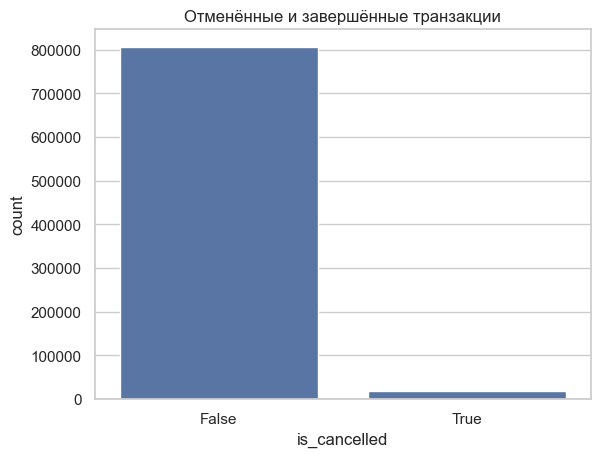

In [ ]:
sns.countplot(data=df, x="is_cancelled")
plt.title("Отменённые и завершённые транзакции")
plt.show()

### Распределение заказов по странам

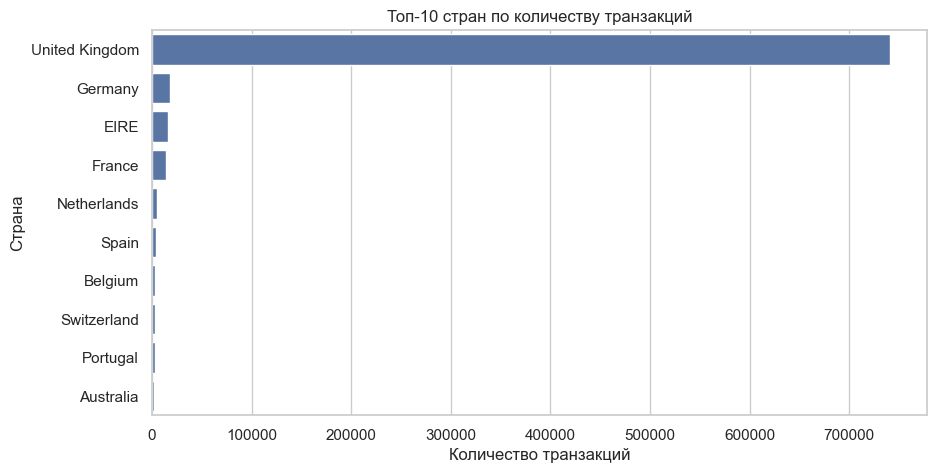

In [ ]:
top_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Топ-10 стран по количеству транзакций")
plt.xlabel("Количество транзакций")
plt.ylabel("Страна")
plt.show()

### Выручка по месяцам

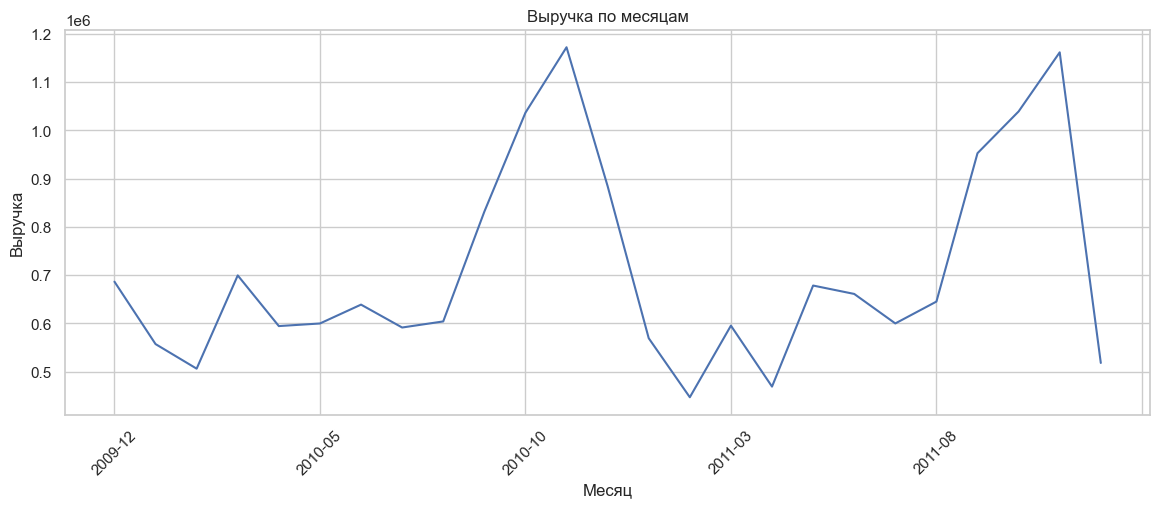

In [ ]:
df_sales = df[
    (df["Quantity"] > 0) &
    (df["Price"] > 0) &
    (~df["is_cancelled"])
].copy()

df_sales["month"] = df_sales["InvoiceDate"].dt.to_period("M").astype(str)

monthly_revenue = df_sales.groupby("month")["Revenue"].sum()

plt.figure(figsize=(14, 5))
monthly_revenue.plot()
plt.title("Выручка по месяцам")
plt.xlabel("Месяц")
plt.ylabel("Выручка")
plt.xticks(rotation=45)
plt.show()

### Распределение количества товаров

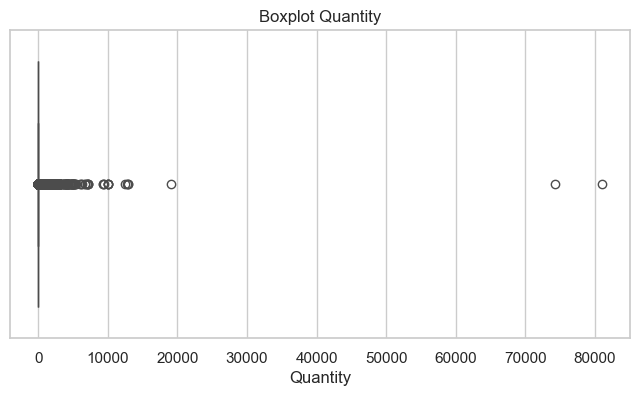

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_sales["Quantity"])
plt.title("Boxplot Quantity")
plt.show()

In [ ]:
df_sales["Quantity"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count    805549.000000
mean         13.290522
std         143.634088
min           1.000000
1%            1.000000
5%            1.000000
50%           5.000000
95%          36.000000
99%         128.000000
max       80995.000000
Name: Quantity, dtype: float64

### Распределение цены

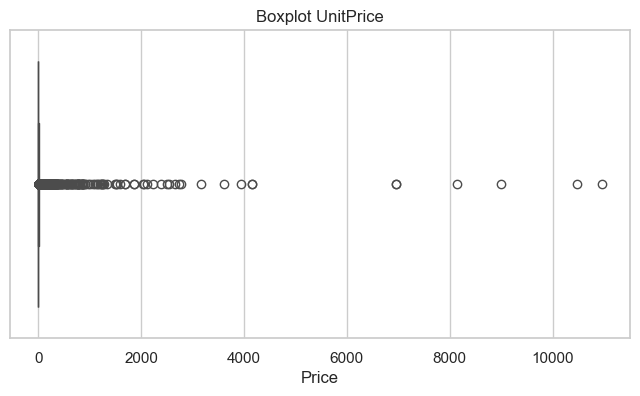

In [ ]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_sales["Price"])
plt.title("Boxplot UnitPrice")
plt.show()

In [ ]:
df_sales["Price"].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

count    805549.000000
mean          3.206561
std          29.199173
min           0.001000
1%            0.290000
5%            0.420000
50%           1.950000
95%           8.500000
99%          14.950000
max       10953.500000
Name: Price, dtype: float64

Выводы по результатам EDA:

1. Общая структура данных. Датасет содержит 824 364 строки и 10 признаков. В данных представлено 5 942 уникальных клиента и 44 876 уникальных заказов. Период наблюдений охватывает почти 2 года: с декабря 2009 года по декабрь 2011 года.

2. Отменённые заказы. Около 2.27% всех транзакций являются отменёнными. Доля небольшая, однако такие записи важно учитывать отдельно, так как они отражают возвраты товаров, ошибки заказов или изменение поведения клиентов.

3. География продаж. Основной объём транзакций приходится на United Kingdom. Количество заказов из Великобритании многократно превышает другие страны, поэтому бизнес ориентирован прежде всего на внутренний рынок. Остальные страны представлены значительно слабее.

4. Динамика выручки. Выручка меняется по месяцам неравномерно. Наблюдаются выраженные сезонные пики в конце 2010 и 2011 года, что может быть связано с рождественским периодом, праздниками и ростом спроса. Такая динамика характерна для магазина подарков. Следовательно, временной фактор играет важную роль и должен учитываться в модели.

5. Количество товаров в заказах. Большинство покупок содержат небольшое количество товаров: медиана = 5 единиц, 95% заказов содержат не более 36 товаров. Однако присутствуют сильные выбросы: максимум = 80 995 единиц. Это могут быть оптовые закупки, корпоративные клиенты. Так, в описании датасета на Kaggle указано, что многие клиенты как раз оптовики. В то же время часть наблюдений может быть результатом ошибки ввода данных.

6. Цена товаров. Большинство товаров имеют невысокую стоимость: медианная цена = £1.95, 95% товаров стоят дешевле £8.50, 99% дешевле £14.95. При этом присутствуют экстремальные значения до £10 953.50.

7. Для построения baseline-модели необходимо обработать выбросы и аномалии:

- отделить завершенные и отменненные заказы
- ограничить экстремальные значения Quantity и Price,
- добавить временные признаки (месяц, сезонность),
- использовать клиентские агрегаты: частота покупок, средний чек, recency, суммарная выручка.

## Подготовка данных

Нужно перейти от транзакций к клиентам.

- total_orders        — число заказов
- total_spent         — сколько потратил
- avg_check           — средний чек
- total_items         — сколько купил товаров
- unique_products     — уникальных товаров
- recency_days        — сколько дней с последней покупки
- customer_age_days   — сколько клиент с нами
- country             — страна
- cancel_rate         — доля отмен

Удаление строк без номера клиента

In [ ]:
sales = df[
    (df["Customer ID"].notna()) &
    (df["Price"] > 0)
].copy()

sales["Customer ID"] = sales["Customer ID"].astype(int)

sales["Customer ID"] = sales["Customer ID"].astype(int)

print("Размер после очистки:", sales.shape)

Размер после очистки: (824293, 10)


Ограничим выбросы

In [ ]:
quantity_99 = sales["Quantity"].quantile(0.99)
price_99 = sales["Price"].quantile(0.99)

sales_clean = sales[
    (sales["Quantity"] <= quantity_99) &
    (sales["Price"] <= price_99)
].copy()

print("До очистки выбросов:", sales.shape)
print("После очистки выбросов:", sales_clean.shape)
print("99% Quantity:", quantity_99)
print("99% Price:", price_99)

До очистки выбросов: (824293, 10)
После очистки выбросов: (808054, 10)
99% Quantity: 120.0
99% Price: 14.95


Настроим таргет.

Будем предсказывать: купит ли клиент снова в следующие 90 дней.

In [ ]:
cutoff_date = sales_clean["InvoiceDate"].max() - pd.Timedelta(days=90)

history = sales_clean[sales_clean["InvoiceDate"] <= cutoff_date].copy()
future = sales_clean[sales_clean["InvoiceDate"] > cutoff_date].copy()

future_customers = set(future["Customer ID"].unique())

customers = history[["Customer ID"]].drop_duplicates().copy()

customers["target_return_90d"] = customers["Customer ID"].apply(
    lambda x: 1 if x in future_customers else 0
)

customers["target_return_90d"].value_counts(normalize=True)

target_return_90d
0    0.561189
1    0.438811
Name: proportion, dtype: float64

Создаем фичи

In [ ]:
features = history.groupby("Customer ID").agg(

    # покупки
    total_orders=("Invoice", "nunique"),
    purchase_items=("Quantity", lambda x: x[x > 0].sum()),
    purchase_revenue=("Revenue", lambda x: x[x > 0].sum()),

    avg_item_price=("Price", lambda x: x[history.loc[x.index, "Quantity"] > 0].mean()),
    avg_quantity=("Quantity", "mean"),

    # возвраты
    return_items=("Quantity", lambda x: x[x < 0].sum()),
    return_count=("is_cancelled", "sum"),
    return_revenue=("Revenue", lambda x: x[x < 0].sum()),

    # разнообразие
    unique_products=("StockCode", "nunique"),
    unique_descriptions=("Description", "nunique"),

    # временные границы
    first_purchase=("InvoiceDate", "min"),
    last_purchase=("InvoiceDate", "max"),

    # флаг возвратов
    has_any_return=("is_cancelled", "max"),
).reset_index()

In [ ]:
features["recency_days"] = (
    cutoff_date - features["last_purchase"]
).dt.days

features["customer_age_days"] = (
    cutoff_date - features["first_purchase"]
).dt.days

In [ ]:
features["orders_per_active_day"] = (
    features["total_orders"] / (features["customer_age_days"] + 1)
)

features["revenue_per_order"] = (
    features["purchase_revenue"] / (features["total_orders"] + 1)
)

features["return_rate_items"] = (
    features["return_items"].abs() /
    (features["purchase_items"] + 1)
)

features["return_rate_orders"] = (
    features["return_count"] /
    (features["total_orders"] + 1)
)

In [ ]:
features = features.drop(columns=[
    "first_purchase",
    "last_purchase"
])

In [ ]:
model_data = customers.merge(features, on="Customer ID", how="left")
model_data = model_data.fillna(0)

model_data.head()

,Customer ID,target_return_90d,total_orders,purchase_items,purchase_revenue,avg_item_price,avg_quantity,return_items,return_count,return_revenue,unique_products,unique_descriptions,has_any_return,recency_days,customer_age_days,orders_per_active_day,revenue_per_order,return_rate_items,return_rate_orders
0,13085,0,9,944,2433.28,3.561071,9.186813,-108,7,-143.70,50,51,True,67,648,0.013867,243.328000,0.114286,0.700000
1,13078,1,79,8285,22820.38,3.941069,11.046008,-122,47,-597.54,142,152,True,9,648,0.121726,285.254750,0.014724,0.587500
2,15362,0,2,368,613.08,3.612000,9.200000,0,0,0.00,38,38,False,358,648,0.003082,204.360000,0.000000,0.000000
3,18102,1,71,25402,89910.10,3.479076,64.641711,-1226,6,-3186.90,205,215,True,35,648,0.109399,1248.751389,0.048262,0.083333
4,12682,1,41,8867,18039.61,2.881701,10.646635,-9,3,-88.10,280,319,True,10,648,0.063174,429.514524,0.001015,0.071429


In [ ]:
model_data["target_return_90d"].value_counts()

target_return_90d
0    2944
1    2302
Name: count, dtype: int64

In [ ]:
model_data["target_return_90d"].value_counts(normalize=True)

target_return_90d
0    0.561189
1    0.438811
Name: proportion, dtype: float64

## Train - Test

In [ ]:
from sklearn.model_selection import train_test_split

train_ids, test_ids = train_test_split(
    model_data["Customer ID"],
    test_size=0.2,
    random_state=42,
    stratify=model_data["target_return_90d"]
)

train = model_data[model_data["Customer ID"].isin(train_ids)]
test = model_data[model_data["Customer ID"].isin(test_ids)]

X_train = train.drop(columns=["Customer ID", "target_return_90d"])
y_train = train["target_return_90d"]

X_test = test.drop(columns=["Customer ID", "target_return_90d"])
y_test = test["target_return_90d"]

X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)

## Выбор моделей и метрик

Для построения baseline были выбраны две классические модели бинарной классификации:
Logistic Regression и Random Forest.

1. Почему выбрана Logistic Regression

Логистическая регрессия является одним из стандартных baseline-алгоритмов для задач классификации.

Преимущества:
- простая и быстрая в обучении;
- хорошо работает на табличных данных;
- устойчива на небольшом количестве признаков;
- даёт интерпретируемые результаты;
- позволяет понять, существует ли линейная зависимость между признаками и целевой переменной.

Эта модель используется как отправная точка, с которой удобно сравнивать более сложные алгоритмы.

2. Почему выбран Random Forest

Random Forest был выбран как более мощная нелинейная ансамблевая модель.

Преимущества:
- хорошо работает на табличных данных;
- умеет находить сложные зависимости между признаками;
- устойчив к шуму и выбросам;
- не требует масштабирования признаков;
- позволяет оценивать важность признаков.

Так как в данных присутствуют выбросы, неравномерность заказов и сложное поведение клиентов, Random Forest подходит как сильный baseline второго уровня.

3. Какая метрика используется для оценки

Основная метрика качества — ROC-AUC.

ROC-AUC показывает способность модели различать два класса:
- клиент вернётся;
- клиент не вернётся.

Почему выбрана именно ROC-AUC:

- подходит для бинарной классификации;
- устойчива к дисбалансу классов;
- оценивает качество ранжирования вероятностей;
- не зависит от конкретного порога классификации.

Интерпретация:
- 0.5 — случайное угадывание
- 0.7+ — хорошая модель
- 0.8+ — сильная модель
- 0.9+ — очень сильная модель

4. Какая ошибка используется

При обучении Logistic Regression минимизируется Log Loss (логарифмическая ошибка).

Log Loss штрафует модель за уверенные неверные прогнозы:
если модель предсказала высокую вероятность возврата клиента, а он не вернулся — штраф высокий.

Для Random Forest напрямую оптимизируется качество разбиений деревьев (Gini / Entropy), а итоговая оценка проводится по ROC-AUC.

Baseline 1 — Logistic Regression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)
y_proba_logreg = logreg.predict_proba(X_test)[:, 1]

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, y_proba_logreg))
print(classification_report(y_test, y_pred_logreg))

Logistic Regression ROC-AUC: 0.7888255029849481
              precision    recall  f1-score   support

           0       0.76      0.70      0.73       589
           1       0.65      0.72      0.69       461

    accuracy                           0.71      1050
   macro avg       0.71      0.71      0.71      1050
weighted avg       0.71      0.71      0.71      1050



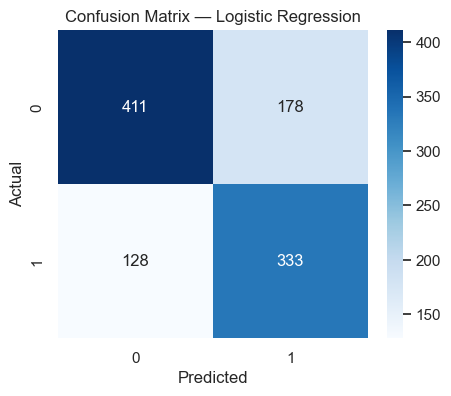

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Baseline 2 — Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest ROC-AUC: 0.7995904673165666
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       589
           1       0.68      0.70      0.69       461

    accuracy                           0.72      1050
   macro avg       0.72      0.72      0.72      1050
weighted avg       0.72      0.72      0.72      1050



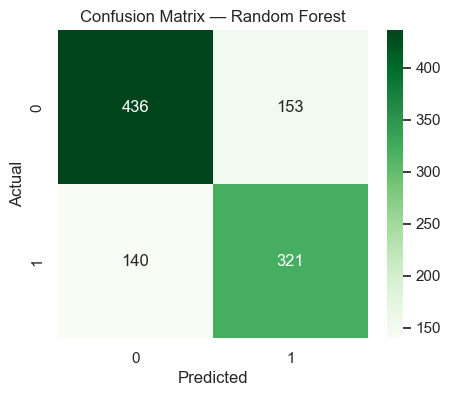

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix — Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

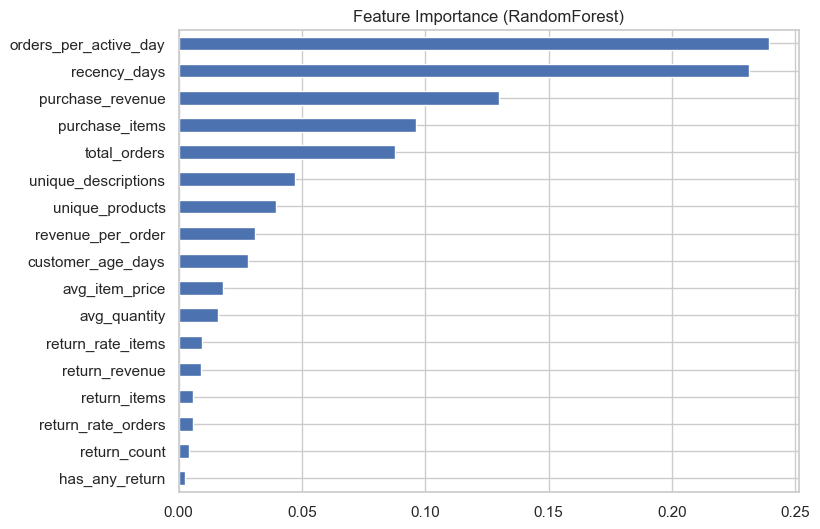

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh')
plt.title("Feature Importance (RandomForest)")
plt.show()

Сравнение

In [ ]:
results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "roc_auc": [
        roc_auc_score(y_test, y_proba_logreg),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

results

,model,roc_auc
0,Logistic Regression,0.788826
1,Random Forest,0.799590


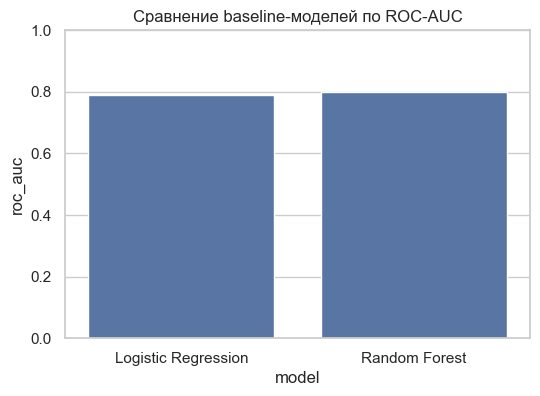

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(data=results, x="model", y="roc_auc")
plt.title("Сравнение baseline-моделей по ROC-AUC")
plt.ylim(0, 1)
plt.show()

1. Результаты сравнения baseline-моделей

По итогам эксперимента были получены результаты:

- Logistic Regression: ROC-AUC ≈ 0.78
- Random Forest: ROC-AUC ≈ 0.8

Random Forest показывает себя чуть лучше

Вывод по сравнению

Полученные результаты означают:

- даже простые агрегированные признаки по клиенту хорошо описывают вероятность повторной покупки;
- линейная модель Logistic Regression уже способна достаточно хорошо решать задачу;
- Random Forest не дал существенного прироста качества, что может означать:
  - признаки уже достаточно информативны;
  - сложных нелинейных зависимостей немного;
  - для улучшения качества нужны новые признаки, а не более сложная модель.

## Работа с аномалиями

### Z-score, межквартильный размах (IQR), тест Граббса

In [ ]:
anomaly_df = model_data.copy()

cols = [
    "purchase_revenue",
    "purchase_items",
    "return_items",
    "recency_days",
    "total_orders"
]

z_values = zscore(anomaly_df[cols])

anomaly_df["z_outlier"] = (np.abs(z_values) > 3).any(axis=1)

def iqr_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    return (df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)

anomaly_df["iqr_outlier"] = (
    iqr_outliers(anomaly_df, "purchase_revenue") |
    iqr_outliers(anomaly_df, "purchase_items") |
    iqr_outliers(anomaly_df, "return_items")
)

def grubbs_test(series):
    mean = series.mean()
    std = series.std()
    z = np.abs((series - mean) / std)
    return z > 3

anomaly_df["grubbs_outlier"] = grubbs_test(anomaly_df["purchase_revenue"])

### Визуализация

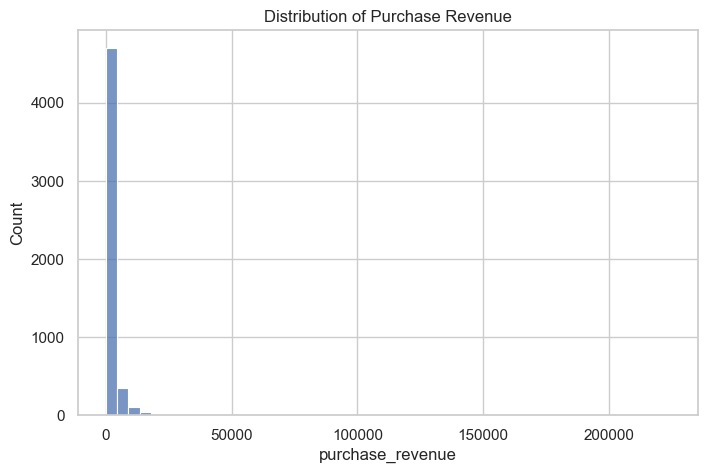

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(anomaly_df["purchase_revenue"], bins=50)
plt.title("Distribution of Purchase Revenue")
plt.show()

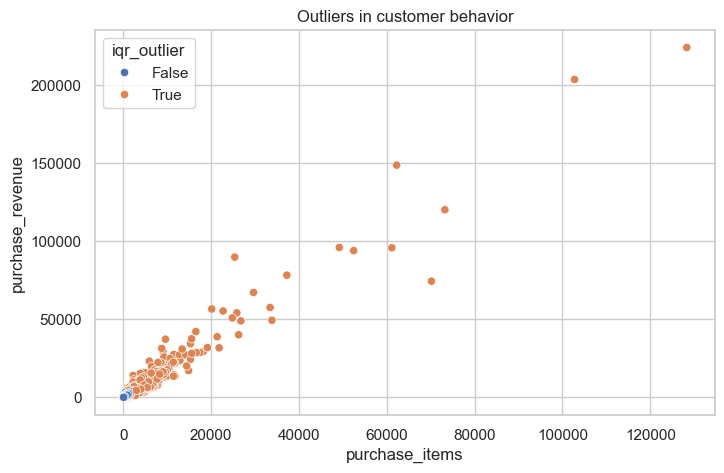

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=anomaly_df,
    x="purchase_items",
    y="purchase_revenue",
    hue="iqr_outlier"
)

plt.title("Outliers in customer behavior")
plt.show()

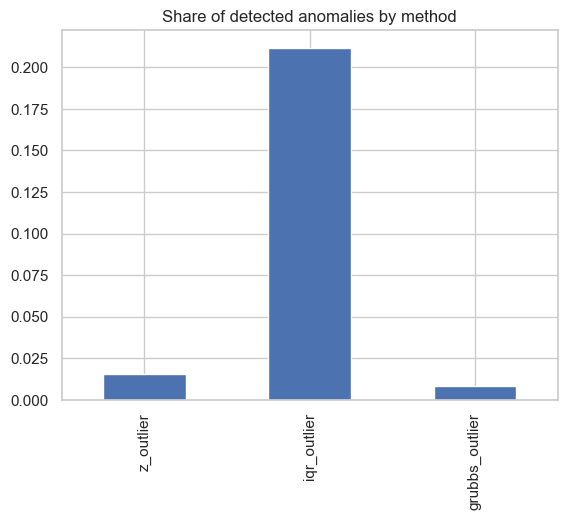

In [ ]:
anomaly_df[[
    "z_outlier",
    "iqr_outlier",
    "grubbs_outlier"
]].mean().plot(kind="bar")

plt.title("Share of detected anomalies by method")
plt.show()

В ходе анализа были выявлены выбросы по ключевым метрикам клиентского поведения. Однако, в контексте e-commerce данные аномалии отражают не ошибки, а различные клиентские сегменты (например, оптовики или корпоративные клиенты). В связи с этим было принято решение не удалять выбросы, а использовать их как дополнительные признаки модели.

### Признаки на основе аномалий

In [ ]:
anomaly_df["anomaly_score"] = (
    anomaly_df["z_outlier"].astype(int) +
    anomaly_df["iqr_outlier"].astype(int) +
    anomaly_df["grubbs_outlier"].astype(int)
)

In [ ]:
anomaly_df["is_any_anomaly"] = (anomaly_df["anomaly_score"] > 0).astype(int)

anomaly_df["is_strong_anomaly"] = (anomaly_df["anomaly_score"] >= 2).astype(int)

In [ ]:
anomaly_df["high_revenue_outlier"] = (
    anomaly_df["purchase_revenue"] >
    anomaly_df["purchase_revenue"].quantile(0.99)
).astype(int)

anomaly_df["high_return_outlier"] = (
    anomaly_df["return_items"].abs() >
    anomaly_df["return_items"].abs().quantile(0.99)
).astype(int)

In [ ]:
# Z-distance
from scipy.stats import zscore

norm_features = [
    "purchase_revenue",
    "purchase_items",
    "return_items",
    "recency_days",
    "total_orders"
]

z_matrix = zscore(anomaly_df[norm_features])

anomaly_df["anomaly_distance"] = np.sqrt((z_matrix ** 2).sum(axis=1))

In [ ]:
# Плотность окружения (LOF distance proxy)
from sklearn.neighbors import NearestNeighbors

X = anomaly_df[norm_features].fillna(0)

knn = NearestNeighbors(n_neighbors=10)
knn.fit(X)

distances, _ = knn.kneighbors(X)

anomaly_df["local_density"] = distances.mean(axis=1)

Были созданы дополнительные признаки на основе аномалий: бинарные индикаторы выбросов, агрегированный score аномальности, а также расстояние до типичного поведения клиентов. Эти признаки позволяют модели учитывать не только уровень активности клиента, но и его отклонение от нормального паттерна поведения.

### ML-методы для поиска сложных выбросов

In [ ]:
features_cols = [
    "purchase_revenue",
    "purchase_items",
    "return_items",
    "recency_days",
    "total_orders",
    "return_rate_items"
]

X_anom = model_data[features_cols].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_anom)

#### Isolation Forest

In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

model_data["iso_anomaly"] = iso.fit_predict(X_scaled)
model_data["iso_anomaly"] = (model_data["iso_anomaly"] == -1).astype(int)

#### LOF (Local Outlier Factor)

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.03
)

model_data["lof_anomaly"] = (lof.fit_predict(X_scaled) == -1).astype(int)

#### One-Class SVM

In [ ]:
from sklearn.svm import OneClassSVM

svm = OneClassSVM(
    nu=0.03,
    kernel="rbf",
    gamma="scale"
)

model_data["svm_anomaly"] = (svm.fit_predict(X_scaled) == -1).astype(int)

#### Визуализация

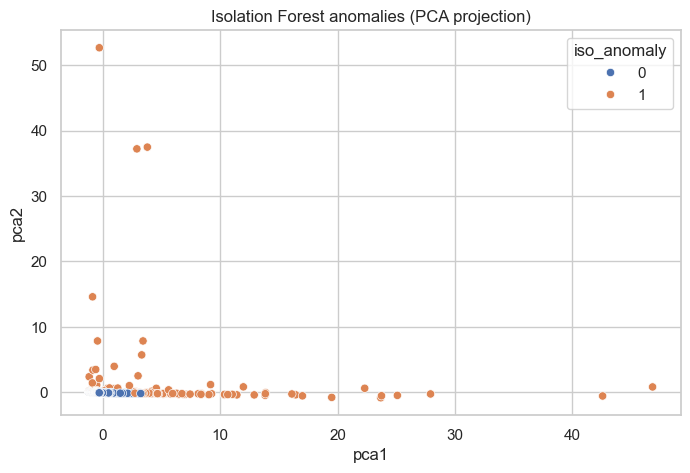

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

viz = model_data.copy()
viz["pca1"] = X_pca[:, 0]
viz["pca2"] = X_pca[:, 1]

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=viz,
    x="pca1",
    y="pca2",
    hue="iso_anomaly"
)

plt.title("Isolation Forest anomalies (PCA projection)")
plt.show()

In [ ]:
comparison = model_data[[
    "iso_anomaly",
    "lof_anomaly",
    "svm_anomaly"
]].mean()

print(comparison)

iso_anomaly    0.030118
lof_anomaly    0.030118
svm_anomaly    0.030118
dtype: float64


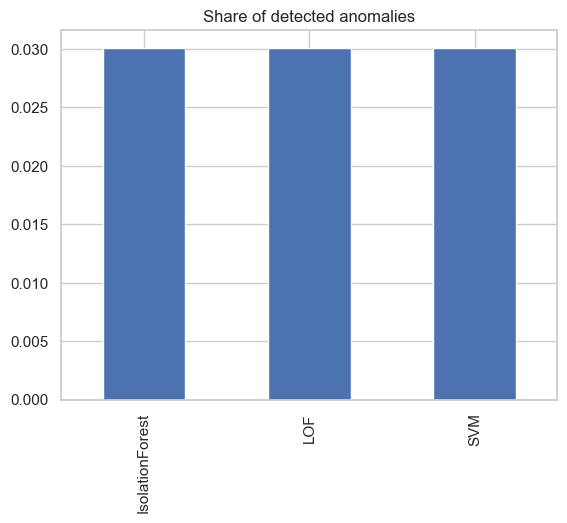

In [ ]:
summary = pd.DataFrame({
    "IsolationForest": model_data["iso_anomaly"],
    "LOF": model_data["lof_anomaly"],
    "SVM": model_data["svm_anomaly"]
}).mean()

summary.plot(kind="bar")
plt.title("Share of detected anomalies")
plt.show()

In [ ]:
model_data["anomaly_agreement"] = (
    model_data["iso_anomaly"] +
    model_data["lof_anomaly"] +
    model_data["svm_anomaly"]
)

model_data["strong_anomaly"] = (model_data["anomaly_agreement"] >= 2).astype(int)

In [ ]:
model_data["strong_anomaly"].value_counts()

strong_anomaly
0    5114
1     132
Name: count, dtype: int64

In [ ]:
model_data.groupby("iso_anomaly")["target_return_90d"].mean()

iso_anomaly
0    0.429442
1    0.740506
Name: target_return_90d, dtype: float64

Доля вервнушихся среди строго аномальных больше. Скорее всего, корпоративные клиенты.

In [ ]:
model_data["anomaly_methods_count"] = (
    model_data["iso_anomaly"] +
    model_data["lof_anomaly"] +
    model_data["svm_anomaly"]
)

In [ ]:
model_data.groupby("anomaly_methods_count")[[
    "purchase_revenue",
    "purchase_items",
    "return_items",
    "target_return_90d"
]].mean()

,purchase_revenue,purchase_items,return_items,target_return_90d
anomaly_methods_count,,,,
0,1515.494925,852.854835,-9.871997,0.432061
1,4501.995037,2409.198758,-79.614907,0.459627
2,14376.631699,6888.433735,-287.578313,0.650602
3,38888.789429,20600.265306,-5593.979592,0.693878


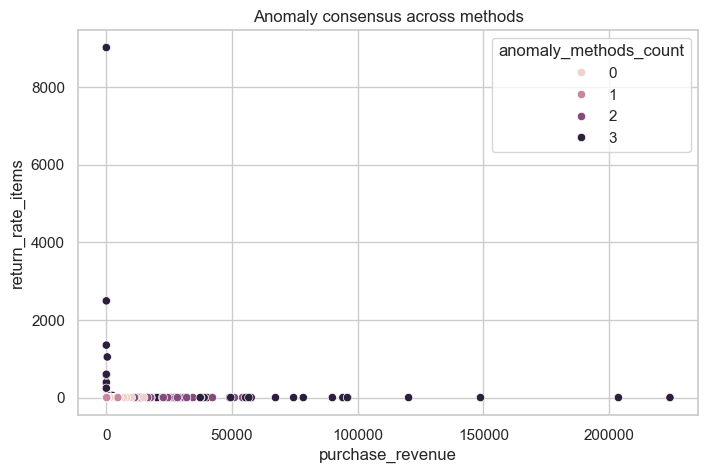

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=model_data,
    x="purchase_revenue",
    y="return_rate_items",
    hue="anomaly_methods_count"
)

plt.title("Anomaly consensus across methods")
plt.show()

In [ ]:
model_data[model_data["anomaly_methods_count"] >= 2].describe()

,Customer ID,target_return_90d,total_orders,purchase_items,purchase_revenue,avg_item_price,avg_quantity,return_items,return_count,return_revenue,...,orders_per_active_day,revenue_per_order,return_rate_items,return_rate_orders,iso_anomaly,lof_anomaly,svm_anomaly,anomaly_agreement,strong_anomaly,anomaly_methods_count
count,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,...,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.000000,132.0,132.000000
mean,15031.416667,0.666667,48.787879,11978.431818,23475.841765,2.694100,-50.455134,-2257.378788,31.681818,-2215.273258,...,0.078462,489.336286,121.522932,1.404955,0.909091,0.659091,0.803030,2.371212,1.0,2.371212
std,1767.008971,0.473200,58.782953,19099.003414,35052.994513,1.504278,269.316930,10125.781148,44.043060,7397.277131,...,0.090012,687.072213,825.786583,2.796216,0.288575,0.475821,0.399224,0.484970,0.0,0.484970
min,12346.000000,0.000000,1.000000,0.000000,0.000000,0.000000,-1802.800000,-87558.000000,0.000000,-77317.670000,...,0.001543,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.0,2.000000
25%,13527.500000,0.000000,7.000000,1170.500000,2153.275000,2.043484,0.000000,-881.500000,5.000000,-1391.475000,...,0.015498,128.193494,0.010060,0.237216,1.000000,0.000000,1.000000,2.000000,1.0,2.000000
50%,14795.500000,1.000000,35.000000,6609.000000,13943.270000,2.646646,10.925422,-289.000000,16.500000,-533.745000,...,0.058383,326.051008,0.027268,0.500000,1.000000,1.000000,1.000000,2.000000,1.0,2.000000
75%,16639.500000,1.000000,68.250000,13635.250000,27713.015000,3.327252,22.782474,-86.000000,39.250000,-196.857500,...,0.108368,576.238624,0.979939,1.302406,1.000000,1.000000,1.000000,3.000000,1.0,3.000000
max,18133.000000,1.000000,355.000000,128291.000000,224201.310000,8.283333,69.891892,0.000000,251.000000,0.000000,...,0.546995,5614.995000,9014.000000,18.500000,1.000000,1.000000,1.000000,3.000000,1.0,3.000000


Isolation Forest выделил небольшую группу пользователей с экстремальными значениями выручки и количества покупок. Эти наблюдения в основном соответствуют крупным или оптовым клиентам, а также пользователям с нетипично высокой активностью.

LOF выявил клиентов, чьё поведение отличается не по абсолютным значениям, а относительно ближайшего окружения. Такие точки часто соответствуют “пограничным” пользователям — с умеренными объёмами покупок, но необычно высокой долей возвратов или нерегулярной активностью.

One-Class SVM оказался наиболее строгим методом и пометил ограниченное число наблюдений как аномальные. Однако часть из них пересекалась с результатами других методов, что подтверждает их устойчивую нетипичность.

Пересечение результатов нескольких моделей позволило выделить наиболее надёжные аномалии.

Анализ показал, что с ростом согласованности методов обнаружения аномалий увеличивается средний масштаб покупок клиентов (выручка и количество товаров). Однако одновременно увеличивается и объём возвратов, а также нестабильность поведения.

Это позволяет интерпретировать аномалии не только как статистические выбросы, но и как поведенческие сегменты клиентов: от стандартных покупателей до высокоактивных клиентов с нестабильным поведением.

Наибольший риск оттока наблюдается в группе устойчивых аномалий, обнаруженных двумя методами (anomaly_methods_count = 2), где вероятность возврата клиента достигает максимального значения среди всех сегментов.

При этом группа с максимальным уровнем аномальности (3 метода) демонстрирует несколько более низкий churn, что может объясняться тем, что в неё попадают крупные корпоративные или оптовые клиенты с высокой бизнес-ценностью и регулярными закупками, несмотря на высокий уровень возвратов.

Таким образом, зависимость между степенью аномальности и churn является нелинейной и отражает наличие различных клиентских сегментов внутри группы выбросов.

# Генерация признаков

Цель этого блока — обогатить клиентский датасет новыми признаками и проверить, дают ли они прирост качества относительно baseline.

Мы добавим четыре группы признаков:

1. **Категориальные признаки**
2. **Признаки ближайших соседей**
3. **Временные признаки**
4. **Контекстные e-commerce признаки**

После этого сравним метрики и проведём отбор признаков тремя подходами: фильтры, wrapper-методы и встроенные методы моделей.

## Подготовка данных для feature engineering

In [ ]:
model_data_fe = model_data.copy()

# Вспомогательная функция для моды
def mode_or_unknown(x):
    m = x.dropna().mode()
    return m.iloc[0] if len(m) > 0 else "Unknown"

print("Размер model_data_fe:", model_data_fe.shape)
print("Доля target=1:", model_data_fe["target_return_90d"].mean().round(3))

Размер model_data_fe: (5246, 25)
Доля target=1: 0.439


In [ ]:
model_data_fe.head()

,Customer ID,target_return_90d,total_orders,purchase_items,purchase_revenue,avg_item_price,avg_quantity,return_items,return_count,return_revenue,...,orders_per_active_day,revenue_per_order,return_rate_items,return_rate_orders,iso_anomaly,lof_anomaly,svm_anomaly,anomaly_agreement,strong_anomaly,anomaly_methods_count
0,13085,0,9,944,2433.28,3.561071,9.186813,-108,7,-143.70,...,0.013867,243.328000,0.114286,0.700000,0,0,0,0,0,0
1,13078,1,79,8285,22820.38,3.941069,11.046008,-122,47,-597.54,...,0.121726,285.254750,0.014724,0.587500,1,0,1,2,1,2
2,15362,0,2,368,613.08,3.612000,9.200000,0,0,0.00,...,0.003082,204.360000,0.000000,0.000000,0,0,0,0,0,0
3,18102,1,71,25402,89910.10,3.479076,64.641711,-1226,6,-3186.90,...,0.109399,1248.751389,0.048262,0.083333,1,1,1,3,1,3
4,12682,1,41,8867,18039.61,2.881701,10.646635,-9,3,-88.10,...,0.063174,429.514524,0.001015,0.071429,1,0,0,1,0,1


## Категориальные признаки

На уровне транзакций есть категориальные признаки `Country`, `StockCode`, `Description`. Для клиентского уровня агрегируем их:

- `country_mode` — основная страна клиента;
- `main_stock_code` — товар, который чаще всего встречался в истории клиента;
- `n_countries` — количество стран в истории клиента.

Далее:

- `country_mode` закодируем через **Target Encoding**;
- самые частые страны дополнительно закодируем через OHE, потому что их немного и они хорошо интерпретируются;
- `main_stock_code` закодируем через Target Encoding, так как у товара высокая кардинальность.

In [ ]:
customer_cat = (
    history
    .groupby("Customer ID")
    .agg(
        country_mode=("Country", mode_or_unknown),
        main_stock_code=("StockCode", mode_or_unknown),
        n_countries=("Country", "nunique")
    )
    .reset_index()
)

model_data_fe = model_data_fe.merge(customer_cat, on="Customer ID", how="left")
model_data_fe["country_mode"] = model_data_fe["country_mode"].fillna("Unknown").astype(str)
model_data_fe["main_stock_code"] = model_data_fe["main_stock_code"].fillna("Unknown").astype(str)
model_data_fe["n_countries"] = model_data_fe["n_countries"].fillna(0)

model_data_fe[["Customer ID", "country_mode", "main_stock_code", "n_countries"]].head()

,Customer ID,country_mode,main_stock_code,n_countries
0,13085,United Kingdom,22041,1
1,13078,United Kingdom,82582,1
2,15362,United Kingdom,20703,1
3,18102,United Kingdom,22171,1
4,12682,France,22352,1


In [ ]:
model_data_fe.head()

,Customer ID,target_return_90d,total_orders,purchase_items,purchase_revenue,avg_item_price,avg_quantity,return_items,return_count,return_revenue,...,return_rate_orders,iso_anomaly,lof_anomaly,svm_anomaly,anomaly_agreement,strong_anomaly,anomaly_methods_count,country_mode,main_stock_code,n_countries
0,13085,0,9,944,2433.28,3.561071,9.186813,-108,7,-143.70,...,0.700000,0,0,0,0,0,0,United Kingdom,22041,1
1,13078,1,79,8285,22820.38,3.941069,11.046008,-122,47,-597.54,...,0.587500,1,0,1,2,1,2,United Kingdom,82582,1
2,15362,0,2,368,613.08,3.612000,9.200000,0,0,0.00,...,0.000000,0,0,0,0,0,0,United Kingdom,20703,1
3,18102,1,71,25402,89910.10,3.479076,64.641711,-1226,6,-3186.90,...,0.083333,1,1,1,3,1,3,United Kingdom,22171,1
4,12682,1,41,8867,18039.61,2.881701,10.646635,-9,3,-88.10,...,0.071429,1,0,0,1,0,1,France,22352,1


In [ ]:
train_fe = model_data_fe[model_data_fe["Customer ID"].isin(train_ids)].copy()
test_fe = model_data_fe[model_data_fe["Customer ID"].isin(test_ids)].copy()

# KFold Target Encoding
def kfold_target_encode(train_df, test_df, col, target_col, n_splits=5, smoothing=20, random_state=42):
    train_encoded = pd.Series(index=train_df.index, dtype=float)
    global_mean = train_df[target_col].mean()

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    for tr_idx, val_idx in skf.split(train_df, train_df[target_col]):
        tr_part = train_df.iloc[tr_idx]
        val_part = train_df.iloc[val_idx]

        stats = tr_part.groupby(col)[target_col].agg(["mean", "count"])
        smooth = (stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)

        train_encoded.iloc[val_idx] = val_part[col].map(smooth).fillna(global_mean)

    # Для test используем mapping, посчитанный только на полном train
    full_stats = train_df.groupby(col)[target_col].agg(["mean", "count"])
    full_smooth = (full_stats["count"] * full_stats["mean"] + smoothing * global_mean) / (full_stats["count"] + smoothing)
    test_encoded = test_df[col].map(full_smooth).fillna(global_mean)

    return train_encoded, test_encoded

for col in ["country_mode", "main_stock_code"]:
    train_fe[f"{col}_te"], test_fe[f"{col}_te"] = kfold_target_encode(
        train_fe, test_fe, col=col, target_col="target_return_90d",
        n_splits=5, smoothing=20
    )

# OHE для самых частых стран: категории выбираем только по train
top_countries = train_fe["country_mode"].value_counts().head(5).index.tolist()

for country in top_countries:
    col_name = "country_ohe_" + str(country).replace(" ", "_").replace("/", "_")
    train_fe[col_name] = (train_fe["country_mode"] == country).astype(int)
    test_fe[col_name] = (test_fe["country_mode"] == country).astype(int)

print("Top countries from train:", top_countries)
train_fe[["country_mode", "country_mode_te", "main_stock_code_te"]].head()

Top countries from train: ['United Kingdom', 'Germany', 'France', 'Spain', 'Belgium']


,country_mode,country_mode_te,main_stock_code_te
0,United Kingdom,0.435244,0.465477
3,United Kingdom,0.434977,0.471001
4,France,0.565770,0.438751
5,United Kingdom,0.432604,0.538514
6,United Kingdom,0.434977,0.491347


In [ ]:
train_fe.head()

,Customer ID,target_return_90d,total_orders,purchase_items,purchase_revenue,avg_item_price,avg_quantity,return_items,return_count,return_revenue,...,country_mode,main_stock_code,n_countries,country_mode_te,main_stock_code_te,country_ohe_United_Kingdom,country_ohe_Germany,country_ohe_France,country_ohe_Spain,country_ohe_Belgium
0,13085,0,9,944,2433.28,3.561071,9.186813,-108,7,-143.70,...,United Kingdom,22041,1,0.435244,0.465477,1,0,0,0,0
3,18102,1,71,25402,89910.10,3.479076,64.641711,-1226,6,-3186.90,...,United Kingdom,22171,1,0.434977,0.471001,1,0,0,0,0
4,12682,1,41,8867,18039.61,2.881701,10.646635,-9,3,-88.10,...,France,22352,1,0.565770,0.438751,0,0,1,0,0
5,18087,0,19,2542,7176.54,3.179231,25.823529,-347,7,-349.90,...,United Kingdom,85123A,1,0.432604,0.538514,1,0,0,0,0
6,13635,1,5,1207,1928.13,2.224800,11.352381,-15,5,-50.94,...,United Kingdom,22111,1,0.434977,0.491347,1,0,0,0,0


## Признаки ближайших соседей

Ищем клиентов, похожих по их прошлому поведению: выручка, количество заказов, товары, возвраты, давность покупки и аномальные флаги.

Создадим признаки:

- `knn_return_rate` — доля вернувшихся среди похожих клиентов из train;
- `knn_avg_revenue` — средняя выручка похожих клиентов;
- `knn_avg_recency` — средняя давность последней покупки похожих клиентов;
- `knn_mean_distance` — насколько клиент похож на ближайших соседей.

Для test ближайшие соседи ищутся только среди train-клиентов, поэтому target test-клиентов не используется.

In [ ]:
# Берём только числовые признаки, доступные до target encoding / без служебных колонок
exclude_cols = ["Customer ID", "target_return_90d", "country_mode", "main_stock_code"]

numeric_cols_for_knn = [
    c for c in train_fe.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(train_fe[c])
]

# Чтобы KNN не строился на уже target-encoded признаках, оставим поведенческие и anomaly-признаки
numeric_cols_for_knn = [
    c for c in numeric_cols_for_knn
    if not c.endswith("_te") and not c.startswith("country_ohe_")
]

scaler_knn = StandardScaler()
X_train_knn = scaler_knn.fit_transform(train_fe[numeric_cols_for_knn].replace([np.inf, -np.inf], np.nan).fillna(0))
X_test_knn = scaler_knn.transform(test_fe[numeric_cols_for_knn].replace([np.inf, -np.inf], np.nan).fillna(0))

k = 5
nn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
nn.fit(X_train_knn)

# Для train первый сосед — сам объект, поэтому его исключаем
dist_train, idx_train = nn.kneighbors(X_train_knn)
dist_train = dist_train[:, 1:]
idx_train = idx_train[:, 1:]

# Для test ищем соседей только в train.
dist_test, idx_test = nn.kneighbors(X_test_knn, n_neighbors=k)

y_train_arr = train_fe["target_return_90d"].to_numpy()
revenue_train_arr = train_fe["purchase_revenue"].to_numpy()
recency_train_arr = train_fe["recency_days"].to_numpy()

train_fe["knn_return_rate"] = y_train_arr[idx_train].mean(axis=1)
test_fe["knn_return_rate"] = y_train_arr[idx_test].mean(axis=1)

train_fe["knn_avg_revenue"] = revenue_train_arr[idx_train].mean(axis=1)
test_fe["knn_avg_revenue"] = revenue_train_arr[idx_test].mean(axis=1)

train_fe["knn_avg_recency"] = recency_train_arr[idx_train].mean(axis=1)
test_fe["knn_avg_recency"] = recency_train_arr[idx_test].mean(axis=1)

train_fe["knn_mean_distance"] = dist_train.mean(axis=1)
test_fe["knn_mean_distance"] = dist_test.mean(axis=1)

train_fe.head()

,Customer ID,target_return_90d,total_orders,purchase_items,purchase_revenue,avg_item_price,avg_quantity,return_items,return_count,return_revenue,...,main_stock_code_te,country_ohe_United_Kingdom,country_ohe_Germany,country_ohe_France,country_ohe_Spain,country_ohe_Belgium,knn_return_rate,knn_avg_revenue,knn_avg_recency,knn_mean_distance
0,13085,0,9,944,2433.28,3.561071,9.186813,-108,7,-143.70,...,0.465477,1,0,0,0,0,0.4,1465.674,42.2,0.764923
3,18102,1,71,25402,89910.10,3.479076,64.641711,-1226,6,-3186.90,...,0.471001,1,0,0,0,0,0.6,56956.292,96.0,8.716738
4,12682,1,41,8867,18039.61,2.881701,10.646635,-9,3,-88.10,...,0.438751,0,0,1,0,0,1.0,16753.678,12.2,1.460626
5,18087,0,19,2542,7176.54,3.179231,25.823529,-347,7,-349.90,...,0.538514,1,0,0,0,0,0.8,5738.476,57.8,0.924187
6,13635,1,5,1207,1928.13,2.224800,11.352381,-15,5,-50.94,...,0.491347,1,0,0,0,0,0.4,2053.666,313.0,0.942022


## Временные признаки

Временные признаки помогают учесть сезонность и привычки клиентов. Добавим:

- признаки последней покупки: час, день недели, месяц;
- синус/косинус-кодирование для циклических переменных;
- долю покупок в выходные;
- долю вечерних покупок;
- долю покупок в декабре как сезонный e-commerce фактор;
- активность за последние 30 дней до cutoff.

In [ ]:
history_time = history.copy()
history_time["hour"] = history_time["InvoiceDate"].dt.hour
history_time["dayofweek"] = history_time["InvoiceDate"].dt.dayofweek
history_time["month"] = history_time["InvoiceDate"].dt.month
history_time["is_weekend"] = history_time["dayofweek"].isin([5, 6]).astype(int)
history_time["is_evening"] = history_time["hour"].between(18, 23).astype(int)
history_time["is_december"] = (history_time["month"] == 12).astype(int)
history_time["is_payday_period"] = history_time["InvoiceDate"].dt.day.ge(25).astype(int) | history_time["InvoiceDate"].dt.day.le(5).astype(int)
history_time["is_payday_period"] = history_time["is_payday_period"].astype(int)

# Последняя покупка клиента
last_purchase_time = (
    history_time
    .sort_values("InvoiceDate")
    .groupby("Customer ID")
    .tail(1)[["Customer ID", "hour", "dayofweek", "month"]]
    .rename(columns={
        "hour": "last_purchase_hour",
        "dayofweek": "last_purchase_dow",
        "month": "last_purchase_month"
    })
)

# Агрегации по истории клиента
time_features = (
    history_time
    .groupby("Customer ID")
    .agg(
        weekend_share=("is_weekend", "mean"),
        evening_share=("is_evening", "mean"),
        december_share=("is_december", "mean"),
        payday_period_share=("is_payday_period", "mean"),
        active_months=("month", "nunique")
    )
    .reset_index()
)

# Активность за последние 30 дней до cutoff
recent_30 = (
    history_time[history_time["InvoiceDate"] >= cutoff_date - pd.Timedelta(days=30)]
    .groupby("Customer ID")
    .agg(orders_last_30d=("Invoice", "nunique"))
    .reset_index()
)

time_features = time_features.merge(last_purchase_time, on="Customer ID", how="left")
time_features = time_features.merge(recent_30, on="Customer ID", how="left")
time_features["orders_last_30d"] = time_features["orders_last_30d"].fillna(0)

# Циклическое кодирование: день недели, месяц, час
time_features["last_dow_sin"] = np.sin(2 * np.pi * time_features["last_purchase_dow"] / 7)
time_features["last_dow_cos"] = np.cos(2 * np.pi * time_features["last_purchase_dow"] / 7)

time_features["last_month_sin"] = np.sin(2 * np.pi * time_features["last_purchase_month"] / 12)
time_features["last_month_cos"] = np.cos(2 * np.pi * time_features["last_purchase_month"] / 12)

time_features["last_hour_sin"] = np.sin(2 * np.pi * time_features["last_purchase_hour"] / 24)
time_features["last_hour_cos"] = np.cos(2 * np.pi * time_features["last_purchase_hour"] / 24)

time_features.head()

,Customer ID,weekend_share,evening_share,december_share,payday_period_share,active_months,last_purchase_hour,last_purchase_dow,last_purchase_month,orders_last_30d,last_dow_sin,last_dow_cos,last_month_sin,last_month_cos,last_hour_sin,last_hour_cos
0,12346,0.000000,0.000000,0.116279,0.813953,5,10,1,1,0.0,0.781831,0.623490,0.500000,0.866025,0.500000,-0.866025
1,12347,0.206186,0.000000,0.319588,0.469072,6,8,1,8,0.0,0.781831,0.623490,-0.866025,-0.500000,0.866025,-0.500000
2,12348,0.000000,0.358974,0.358974,0.641026,4,10,1,4,0.0,0.781831,0.623490,0.866025,-0.500000,0.500000,-0.866025
3,12349,0.000000,0.000000,0.048544,1.000000,3,8,3,10,0.0,0.433884,-0.900969,-0.866025,0.500000,0.866025,-0.500000
4,12350,0.000000,0.000000,0.000000,1.000000,1,16,2,2,0.0,0.974928,-0.222521,0.866025,0.500000,-0.866025,-0.500000


In [ ]:
train_fe = train_fe.merge(time_features, on="Customer ID", how="left")
test_fe = test_fe.merge(time_features, on="Customer ID", how="left")

for df_part in [train_fe, test_fe]:
    df_part[time_features.columns.drop("Customer ID")] = df_part[time_features.columns.drop("Customer ID")].fillna(0)

train_fe.head()

,Customer ID,target_return_90d,total_orders,purchase_items,purchase_revenue,avg_item_price,avg_quantity,return_items,return_count,return_revenue,...,last_purchase_hour,last_purchase_dow,last_purchase_month,orders_last_30d,last_dow_sin,last_dow_cos,last_month_sin,last_month_cos,last_hour_sin,last_hour_cos
0,13085,0,9,944,2433.28,3.561071,9.186813,-108,7,-143.70,...,12,1,7,0.0,0.781831,0.623490,-0.500000,-8.660254e-01,1.224647e-16,-1.000000
1,18102,1,71,25402,89910.10,3.479076,64.641711,-1226,6,-3186.90,...,15,4,8,0.0,-0.433884,-0.900969,-0.866025,-5.000000e-01,-7.071068e-01,-0.707107
2,12682,1,41,8867,18039.61,2.881701,10.646635,-9,3,-88.10,...,12,2,8,3.0,0.974928,-0.222521,-0.866025,-5.000000e-01,1.224647e-16,-1.000000
3,18087,0,19,2542,7176.54,3.179231,25.823529,-347,7,-349.90,...,13,0,7,0.0,0.000000,1.000000,-0.500000,-8.660254e-01,-2.588190e-01,-0.965926
4,13635,1,5,1207,1928.13,2.224800,11.352381,-15,5,-50.94,...,17,1,9,0.0,0.781831,0.623490,-1.000000,-1.836970e-16,-9.659258e-01,-0.258819


## Контекстные признаки e-commerce

Добавим признаки, отражающие бизнес-логику интернет-магазина:

- `avg_items_per_order` — среднее количество купленных товаров на заказ;
- `revenue_per_item` — средняя выручка на товар;
- `products_per_order` — разнообразие товаров на заказ;
- `order_frequency_30d` — нормированная частота заказов за 30 дней;
- `return_pressure` — нагрузка возвратами относительно числа заказов;
- `bulk_customer_flag` — флаг клиента с крупными заказами. Порог считается только на train.

In [ ]:
for df_part in [train_fe, test_fe]:
    df_part["avg_items_per_order"] = df_part["purchase_items"] / (df_part["total_orders"] + 1)
    df_part["revenue_per_item"] = df_part["purchase_revenue"] / (df_part["purchase_items"] + 1)
    df_part["products_per_order"] = df_part["unique_products"] / (df_part["total_orders"] + 1)
    df_part["descriptions_per_order"] = df_part["unique_descriptions"] / (df_part["total_orders"] + 1)
    df_part["order_frequency_30d"] = 30 * df_part["total_orders"] / (df_part["customer_age_days"] + 1)
    df_part["return_pressure"] = df_part["return_count"] / (df_part["total_orders"] + 1)
    df_part["recent_activity_share"] = df_part["orders_last_30d"] / (df_part["total_orders"] + 1)

# Порог клиента-оптовика считаем только на train
bulk_threshold = train_fe["avg_items_per_order"].quantile(0.90)
train_fe["bulk_customer_flag"] = (train_fe["avg_items_per_order"] >= bulk_threshold).astype(int)
test_fe["bulk_customer_flag"] = (test_fe["avg_items_per_order"] >= bulk_threshold).astype(int)

context_cols = [
    "avg_items_per_order", "revenue_per_item", "products_per_order",
    "descriptions_per_order", "order_frequency_30d", "return_pressure",
    "recent_activity_share", "bulk_customer_flag"
]

train_fe.head()

,Customer ID,target_return_90d,total_orders,purchase_items,purchase_revenue,avg_item_price,avg_quantity,return_items,return_count,return_revenue,...,last_hour_sin,last_hour_cos,avg_items_per_order,revenue_per_item,products_per_order,descriptions_per_order,order_frequency_30d,return_pressure,recent_activity_share,bulk_customer_flag
0,13085,0,9,944,2433.28,3.561071,9.186813,-108,7,-143.70,...,1.224647e-16,-1.000000,94.400000,2.574899,5.000000,5.100000,0.416025,0.700000,0.000000,0
1,18102,1,71,25402,89910.10,3.479076,64.641711,-1226,6,-3186.90,...,-7.071068e-01,-0.707107,352.805556,3.539350,2.847222,2.986111,3.281972,0.083333,0.000000,1
2,12682,1,41,8867,18039.61,2.881701,10.646635,-9,3,-88.10,...,1.224647e-16,-1.000000,211.119048,2.034237,6.666667,7.595238,1.895223,0.071429,0.071429,0
3,18087,0,19,2542,7176.54,3.179231,25.823529,-347,7,-349.90,...,-2.588190e-01,-0.965926,127.100000,2.822076,2.100000,2.250000,0.878274,0.350000,0.000000,0
4,13635,1,5,1207,1928.13,2.224800,11.352381,-15,5,-50.94,...,-9.659258e-01,-0.258819,201.166667,1.596134,15.000000,15.000000,0.231125,0.833333,0.000000,0


## Обучение моделей на расширенном наборе признаков

Сравним результат с baseline. Для честного сравнения используем тот же train/test split и ту же основную метрику — ROC-AUC.

In [ ]:
drop_cols = [
    "Customer ID", "target_return_90d", "country_mode", "main_stock_code"
]

X_train_fe = train_fe.drop(columns=[c for c in drop_cols if c in train_fe.columns])
X_test_fe = test_fe.drop(columns=[c for c in drop_cols if c in test_fe.columns])

y_train_fe = train_fe["target_return_90d"]
y_test_fe = test_fe["target_return_90d"]

# Оставляем только числовые признаки
X_train_fe = X_train_fe.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0)
X_test_fe = X_test_fe[X_train_fe.columns].replace([np.inf, -np.inf], np.nan).fillna(0)

print("Количество признаков после feature engineering:", X_train_fe.shape[1])
print("Train shape:", X_train_fe.shape)
print("Test shape:", X_test_fe.shape)

Количество признаков после feature engineering: 57
Train shape: (4196, 57)
Test shape: (1050, 57)


In [ ]:
logreg_fe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_fe.fit(X_train_fe, y_train_fe)
y_proba_logreg_fe = logreg_fe.predict_proba(X_test_fe)[:, 1]
y_pred_logreg_fe = logreg_fe.predict(X_test_fe)

rf_fe = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_fe.fit(X_train_fe, y_train_fe)
y_proba_rf_fe = rf_fe.predict_proba(X_test_fe)[:, 1]
y_pred_rf_fe = rf_fe.predict(X_test_fe)

results_fe = pd.DataFrame({
    "model": [
        "Baseline Logistic Regression",
        "Baseline Random Forest",
        "Feature Engineering Logistic Regression",
        "Feature Engineering Random Forest"
    ],
    "roc_auc": [
        roc_auc_score(y_test, y_proba_logreg),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test_fe, y_proba_logreg_fe),
        roc_auc_score(y_test_fe, y_proba_rf_fe)
    ]
})

results_fe

,model,roc_auc
0,Baseline Logistic Regression,0.788826
1,Baseline Random Forest,0.799590
2,Feature Engineering Logistic Regression,0.799082
3,Feature Engineering Random Forest,0.797465


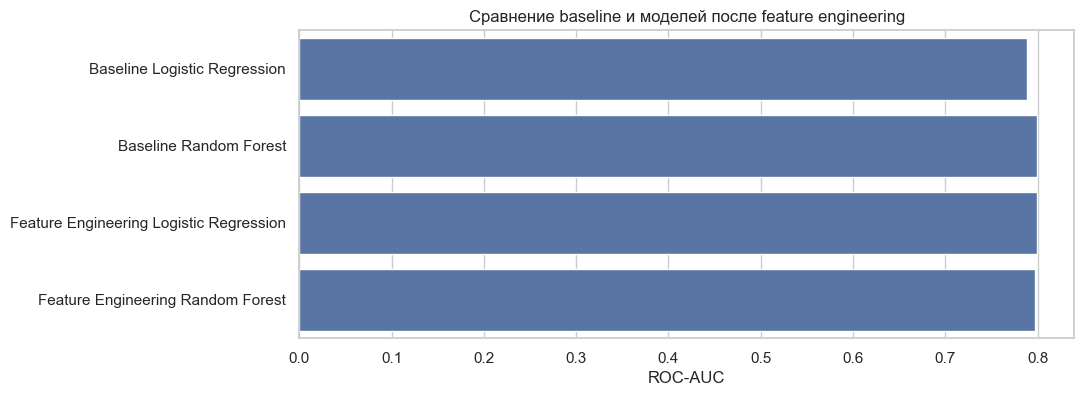

Feature Engineering Logistic Regression
              precision    recall  f1-score   support

           0       0.76      0.74      0.75       589
           1       0.68      0.71      0.69       461

    accuracy                           0.73      1050
   macro avg       0.72      0.72      0.72      1050
weighted avg       0.73      0.73      0.73      1050

Feature Engineering Random Forest
              precision    recall  f1-score   support

           0       0.74      0.74      0.74       589
           1       0.67      0.67      0.67       461

    accuracy                           0.71      1050
   macro avg       0.71      0.71      0.71      1050
weighted avg       0.71      0.71      0.71      1050



In [ ]:
plt.figure(figsize=(10, 4))
sns.barplot(data=results_fe, x="roc_auc", y="model")
plt.title("Сравнение baseline и моделей после feature engineering")
plt.xlabel("ROC-AUC")
plt.ylabel("")
plt.show()

print("Feature Engineering Logistic Regression")
print(classification_report(y_test_fe, y_pred_logreg_fe))

print("Feature Engineering Random Forest")
print(classification_report(y_test_fe, y_pred_rf_fe))

После генерации новых признаков качество логистической регрессии улучшилось: ROC-AUC вырос с 0.789 до 0.799. Это говорит о том, что новые признаки сделали зависимости более линейно разделимыми и помогли простой модели лучше различать клиентов, которые вернутся, и тех, кто не вернётся. Для Random Forest качество немного снизилось: ROC-AUC изменился с 0.800 до 0.797. Вероятно, часть новых признаков оказалась шумовой или дублировала уже существующую информацию. Так как снижение небольшое, можно считать, что feature engineering не ухудшил решение существенно, но не дал стабильного прироста для всех моделей.

# Отбор признаков

## Фильтры

Используем два фильтра:

- `mutual_info_classif` — находит нелинейную связь признака с target;
- `f_classif` / ANOVA — оценивает различие средних значений признака между классами.

Эти методы быстрые и дают первичное понимание, какие признаки наиболее информативны.

In [ ]:
mi_scores = mutual_info_classif(X_train_fe, y_train_fe, random_state=42)
f_scores, f_pvalues = f_classif(X_train_fe, y_train_fe)

filter_scores = pd.DataFrame({
    "feature": X_train_fe.columns,
    "mutual_info": mi_scores,
    "anova_f": f_scores,
    "anova_pvalue": f_pvalues
}).sort_values("mutual_info", ascending=False)

filter_scores.head(15)

,feature,mutual_info,anova_f,anova_pvalue
53,order_frequency_30d,0.140847,294.482984,7.579521e-64
12,orders_per_active_day,0.140680,294.482984,7.579521e-64
10,recency_days,0.121138,1080.692661,4.353236e-211
32,knn_avg_recency,0.115104,1055.333487,1.076278e-206
1,purchase_items,0.112733,164.736618,5.150668e-37
38,active_months,0.112703,1026.450087,1.152408e-201
31,knn_avg_revenue,0.107237,233.760047,2.144219e-51
2,purchase_revenue,0.104465,162.517888,1.507866e-36
0,total_orders,0.103970,329.541243,5.906881e-71
30,knn_return_rate,0.094367,912.391172,1.587357e-181


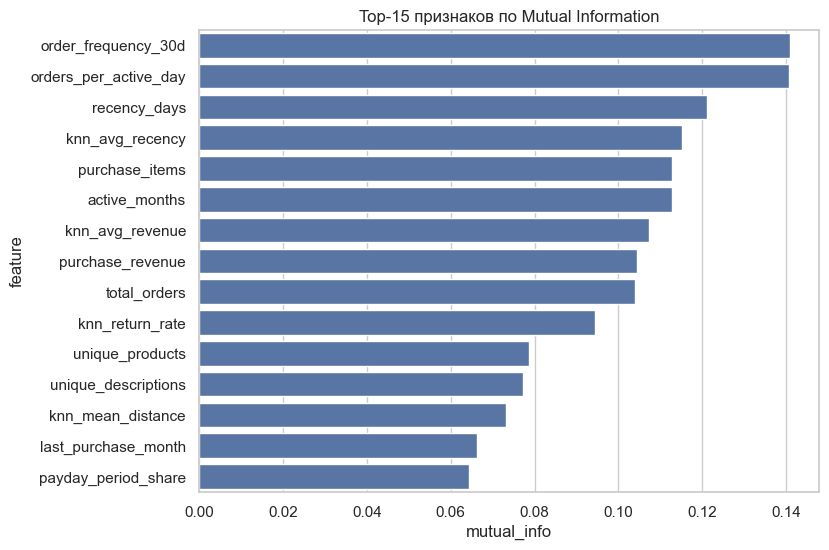

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=filter_scores.head(15),
    x="mutual_info",
    y="feature"
)
plt.title("Top-15 признаков по Mutual Information")
plt.show()

## Wrapper-подход

В качестве wrapper-метода используем RFECV: модель обучается несколько раз на разных подмножествах признаков, а качество оценивается через кросс-валидацию.

Чтобы расчёт не был слишком долгим, ограничим входные признаки топ-30 по Mutual Information.

In [ ]:
top_filter_features = filter_scores.head(30)["feature"].tolist()

scaler_rfe = StandardScaler()
X_train_rfe_scaled = scaler_rfe.fit_transform(X_train_fe[top_filter_features])

rfe_estimator = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

rfecv = RFECV(
    estimator=rfe_estimator,
    step=1,
    cv=5,
    scoring="roc_auc",
    min_features_to_select=5,
    n_jobs=-1
)

rfecv.fit(X_train_rfe_scaled, y_train_fe)

rfe_features = pd.Series(top_filter_features)[rfecv.support_].tolist()
print("Оптимальное число признаков по RFECV:", len(rfe_features))
print(rfe_features)

Оптимальное число признаков по RFECV: 23
['order_frequency_30d', 'orders_per_active_day', 'recency_days', 'purchase_items', 'active_months', 'knn_avg_revenue', 'purchase_revenue', 'total_orders', 'knn_return_rate', 'unique_products', 'unique_descriptions', 'knn_mean_distance', 'last_purchase_month', 'payday_period_share', 'return_rate_orders', 'return_pressure', 'products_per_order', 'recent_activity_share', 'orders_last_30d', 'avg_items_per_order', 'return_rate_items', 'return_items', 'revenue_per_order']


In [ ]:
# Проверим качество на признаках, выбранных RFECV.
logreg_rfe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_rfe.fit(X_train_fe[rfe_features], y_train_fe)
y_proba_rfe = logreg_rfe.predict_proba(X_test_fe[rfe_features])[:, 1]

print("ROC-AUC Logistic Regression на RFECV-признаках:", roc_auc_score(y_test_fe, y_proba_rfe))

ROC-AUC Logistic Regression на RFECV-признаках: 0.7963421954929307


После отбора признаков с помощью RFECV качество Logistic Regression немного снизилось с 0.799 до 0.796 ROC-AUC. Это означает, что RFECV позволил сократить набор признаков, но часть удалённых переменных всё ещё содержала полезный сигнал для тестовой выборки. Снижение качества небольшое, поэтому отбор признаков можно рассматривать не как способ улучшения метрики, а как способ упростить модель и выделить наиболее устойчивые признаки.

## Встроенные методы

Используем два встроенных подхода:

1. L1-регуляризация в Logistic Regression — зануляет слабые коэффициенты.
2. Feature Importance у Random Forest — показывает, какие признаки чаще используются в деревьях для хороших разбиений.

In [ ]:
l1_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=0.1,
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

l1_model.fit(X_train_fe, y_train_fe)
l1_coef = l1_model.named_steps["model"].coef_[0]

l1_features = (
    pd.DataFrame({"feature": X_train_fe.columns, "coef": l1_coef})
    .assign(abs_coef=lambda x: x["coef"].abs())
    .sort_values("abs_coef", ascending=False)
)

selected_l1_features = l1_features[l1_features["abs_coef"] > 0]["feature"].tolist()
print("Количество признаков с ненулевым L1-коэффициентом:", len(selected_l1_features))
l1_features.head(15)

Количество признаков с ненулевым L1-коэффициентом: 34


c:\Users\Adelia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\Adelia\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,feature,coef,abs_coef
38,active_months,0.609962,0.609962
10,recency_days,-0.564799,0.564799
42,orders_last_30d,0.191358,0.191358
9,unique_descriptions,0.168079,0.168079
49,avg_items_per_order,0.149940,0.149940
11,customer_age_days,-0.134165,0.134165
3,avg_item_price,-0.113700,0.113700
30,knn_return_rate,0.110222,0.110222
41,last_purchase_month,0.084374,0.084374
12,orders_per_active_day,0.083700,0.083700


In [ ]:
rf_importances = (
    pd.DataFrame({
        "feature": X_train_fe.columns,
        "importance": rf_fe.feature_importances_
    })
    .sort_values("importance", ascending=False)
)

rf_top_features = rf_importances.head(25)["feature"].tolist()
rf_importances.head(15)

,feature,importance
53,order_frequency_30d,0.109941
32,knn_avg_recency,0.109457
10,recency_days,0.102625
12,orders_per_active_day,0.100860
31,knn_avg_revenue,0.058454
2,purchase_revenue,0.057563
0,total_orders,0.051994
38,active_months,0.043386
1,purchase_items,0.037968
9,unique_descriptions,0.032376


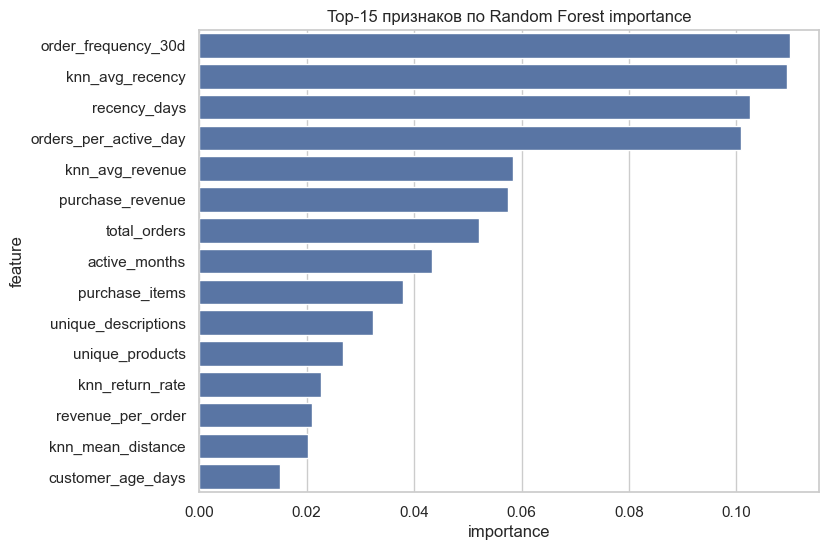

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=rf_importances.head(15),
    x="importance",
    y="feature"
)
plt.title("Top-15 признаков по Random Forest importance")
plt.show()

In [ ]:
# Финальный набор: признаки, которые попали хотя бы в один из сильных списков
final_selected_features = sorted(set(rfe_features) | set(selected_l1_features) | set(rf_top_features))

print("Итоговое число отобранных признаков:", len(final_selected_features))
print(final_selected_features)

Итоговое число отобранных признаков: 45
['active_months', 'avg_item_price', 'avg_items_per_order', 'avg_quantity', 'bulk_customer_flag', 'country_mode_te', 'country_ohe_Germany', 'country_ohe_Spain', 'country_ohe_United_Kingdom', 'customer_age_days', 'december_share', 'descriptions_per_order', 'evening_share', 'knn_avg_recency', 'knn_avg_revenue', 'knn_mean_distance', 'knn_return_rate', 'last_dow_sin', 'last_hour_cos', 'last_month_sin', 'last_purchase_hour', 'last_purchase_month', 'lof_anomaly', 'main_stock_code_te', 'order_frequency_30d', 'orders_last_30d', 'orders_per_active_day', 'payday_period_share', 'products_per_order', 'purchase_items', 'purchase_revenue', 'recency_days', 'recent_activity_share', 'return_items', 'return_pressure', 'return_rate_items', 'return_rate_orders', 'return_revenue', 'revenue_per_item', 'revenue_per_order', 'strong_anomaly', 'total_orders', 'unique_descriptions', 'unique_products', 'weekend_share']


In [ ]:
rf_selected = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_selected.fit(X_train_fe[final_selected_features], y_train_fe)
y_proba_rf_selected = rf_selected.predict_proba(X_test_fe[final_selected_features])[:, 1]

logreg_selected = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_selected.fit(X_train_fe[final_selected_features], y_train_fe)
y_proba_logreg_selected = logreg_selected.predict_proba(X_test_fe[final_selected_features])[:, 1]

selection_results = pd.DataFrame({
    "model": [
        "FE Logistic Regression all features",
        "FE Random Forest all features",
        "Selected Logistic Regression",
        "Selected Random Forest"
    ],
    "roc_auc": [
        roc_auc_score(y_test_fe, y_proba_logreg_fe),
        roc_auc_score(y_test_fe, y_proba_rf_fe),
        roc_auc_score(y_test_fe, y_proba_logreg_selected),
        roc_auc_score(y_test_fe, y_proba_rf_selected)
    ]
})

selection_results

,model,roc_auc
0,FE Logistic Regression all features,0.799082
1,FE Random Forest all features,0.797465
2,Selected Logistic Regression,0.797594
3,Selected Random Forest,0.797565


После отбора признаков качество Logistic Regression немного снизилось с 0.799 до 0.798 ROC-AUC, а качество Random Forest осталось практически на том же уровне: 0.7975 против 0.7976. Это показывает, что новые признаки содержат полезный сигнал, но часть этого сигнала распределена между многими слабыми переменными. Отбор признаков не привёл к заметному росту ROC-AUC, однако позволил упростить модель и оставить наиболее устойчивые признаки без существенной потери качества.

## Проверка нестабильных признаков во времени

Проверим, какие признаки сильно меняют распределение между более ранними и более поздними клиентскими когортами. Для этого используем PSI — Population Stability Index.

Интерпретация PSI:

- `< 0.1` — распределение стабильно;
- `0.1–0.25` — есть умеренный сдвиг;
- `> 0.25` — сильный сдвиг, признак потенциально нестабилен во времени.

In [ ]:
# Добавим дату первой покупки для когорты.
first_purchase_dt = (
    history
    .groupby("Customer ID")
    .agg(first_purchase_dt=("InvoiceDate", "min"))
    .reset_index()
)

stability_df = pd.concat([train_fe, test_fe], axis=0).merge(first_purchase_dt, on="Customer ID", how="left")
stability_df = stability_df.dropna(subset=["first_purchase_dt"])

median_first_purchase = stability_df["first_purchase_dt"].median()
early = stability_df[stability_df["first_purchase_dt"] <= median_first_purchase]
late = stability_df[stability_df["first_purchase_dt"] > median_first_purchase]

print("Median first purchase:", median_first_purchase)
print("Early cohort size:", early.shape[0])
print("Late cohort size:", late.shape[0])

Median first purchase: 2010-05-20 16:47:00
Early cohort size: 2623
Late cohort size: 2623


In [ ]:
def calculate_psi(expected, actual, buckets=10):
    expected = pd.Series(expected).replace([np.inf, -np.inf], np.nan).dropna()
    actual = pd.Series(actual).replace([np.inf, -np.inf], np.nan).dropna()

    if expected.nunique() <= 1 or actual.nunique() <= 1:
        return 0

    quantiles = np.linspace(0, 1, buckets + 1)
    breakpoints = np.unique(np.quantile(expected, quantiles))

    if len(breakpoints) < 3:
        return 0

    expected_counts = pd.cut(expected, bins=breakpoints, include_lowest=True).value_counts(normalize=True, sort=False)
    actual_counts = pd.cut(actual, bins=breakpoints, include_lowest=True).value_counts(normalize=True, sort=False)

    expected_pct = expected_counts.replace(0, 1e-6)
    actual_pct = actual_counts.reindex(expected_pct.index).fillna(1e-6).replace(0, 1e-6)

    psi = ((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)).sum()
    return psi

psi_scores = []
for col in final_selected_features:
    psi_scores.append({
        "feature": col,
        "psi": calculate_psi(early[col], late[col])
    })

psi_df = pd.DataFrame(psi_scores).sort_values("psi", ascending=False)
psi_df.head(15)

,feature,psi
9,customer_age_days,12.338446
31,recency_days,2.395795
26,orders_per_active_day,1.284764
24,order_frequency_30d,1.284764
0,active_months,0.930438
41,total_orders,0.904329
14,knn_avg_revenue,0.761699
13,knn_avg_recency,0.759398
30,purchase_revenue,0.699738
29,purchase_items,0.604202


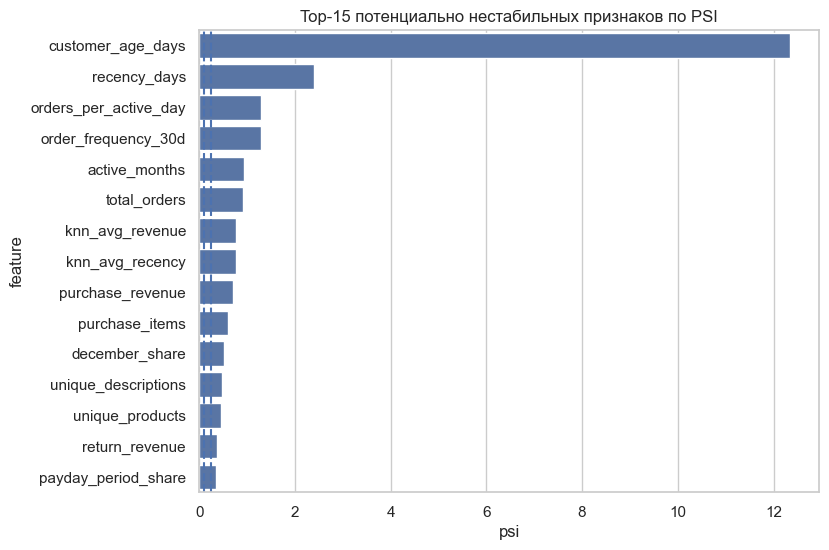

In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(
    data=psi_df.head(15),
    x="psi",
    y="feature"
)
plt.axvline(0.10, linestyle="--")
plt.axvline(0.25, linestyle="--")
plt.title("Top-15 потенциально нестабильных признаков по PSI")
plt.show()

Проверка временной стабильности показала, что часть признаков имеет выраженный сдвиг распределения. Наиболее нестабильным оказался customer_age_days, что ожидаемо: возраст клиента увеличивается вместе с календарным временем. Также сдвиг наблюдается у признаков, связанных с давностью и частотой покупок (recency_days, orders_per_active_day, order_frequency_30d, active_months). Мы не удаляем эти признаки автоматически, так как они отражают важное поведение клиента, но учитываем риск нестабильности и используем их осторожно при интерпретации модели.

# Интерпретация и диагностика моделей

На этом этапе смотрим не только на ROC-AUC, но и на то, **почему модель принимает решения**:

- какие признаки сильнее всего влияют на прогноз;
- совпадают ли выводы для линейной модели и ансамбля деревьев;
- есть ли группы клиентов, для которых модель ведёт себя иначе;
- можно ли найти сдвиги и аномалии не в исходных признаках, а во вкладах признаков через SHAP.

В качестве двух разных классов моделей используем:

1. **Logistic Regression**
2. **Random Forest**

In [ ]:
interpretation_features = final_selected_features.copy()
print("Количество признаков для интерпретации:", len(interpretation_features))
print(interpretation_features[:20])

Количество признаков для интерпретации: 45
['active_months', 'avg_item_price', 'avg_items_per_order', 'avg_quantity', 'bulk_customer_flag', 'country_mode_te', 'country_ohe_Germany', 'country_ohe_Spain', 'country_ohe_United_Kingdom', 'customer_age_days', 'december_share', 'descriptions_per_order', 'evening_share', 'knn_avg_recency', 'knn_avg_revenue', 'knn_mean_distance', 'knn_return_rate', 'last_dow_sin', 'last_hour_cos', 'last_month_sin']


In [ ]:
# Финальные матрицы для интерпретации
X_train_int = X_train_fe[interpretation_features].replace([np.inf, -np.inf], np.nan).fillna(0).copy()
X_test_int = X_test_fe[interpretation_features].replace([np.inf, -np.inf], np.nan).fillna(0).copy()
y_train_int = y_train_fe.copy()
y_test_int = y_test_fe.copy()

# Линейная модель
logreg_int = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

logreg_int.fit(X_train_int, y_train_int)
y_proba_logreg_int = logreg_int.predict_proba(X_test_int)[:, 1]

# Ансамблевая модель
rf_int = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_int.fit(X_train_int, y_train_int)
y_proba_rf_int = rf_int.predict_proba(X_test_int)[:, 1]

interpretation_results = pd.DataFrame({
    "model": ["Logistic Regression для интерпретации", "Random Forest для интерпретации"],
    "roc_auc": [
        roc_auc_score(y_test_int, y_proba_logreg_int),
        roc_auc_score(y_test_int, y_proba_rf_int)
    ]
})

interpretation_results


,model,roc_auc
0,Logistic Regression для интерпретации,0.797594
1,Random Forest для интерпретации,0.797565


## Глобальная интерпретация моделей через SHAP и LIME

Глобальная интерпретация отвечает на вопрос: **какие признаки в среднем сильнее всего влияют на прогноз модели**.

Для линейной модели направление влияния обычно проще: положительный вклад увеличивает вероятность возврата клиента, отрицательный — уменьшает. Для Random Forest влияние может быть нелинейным: один и тот же признак может работать по-разному для разных групп клиентов.

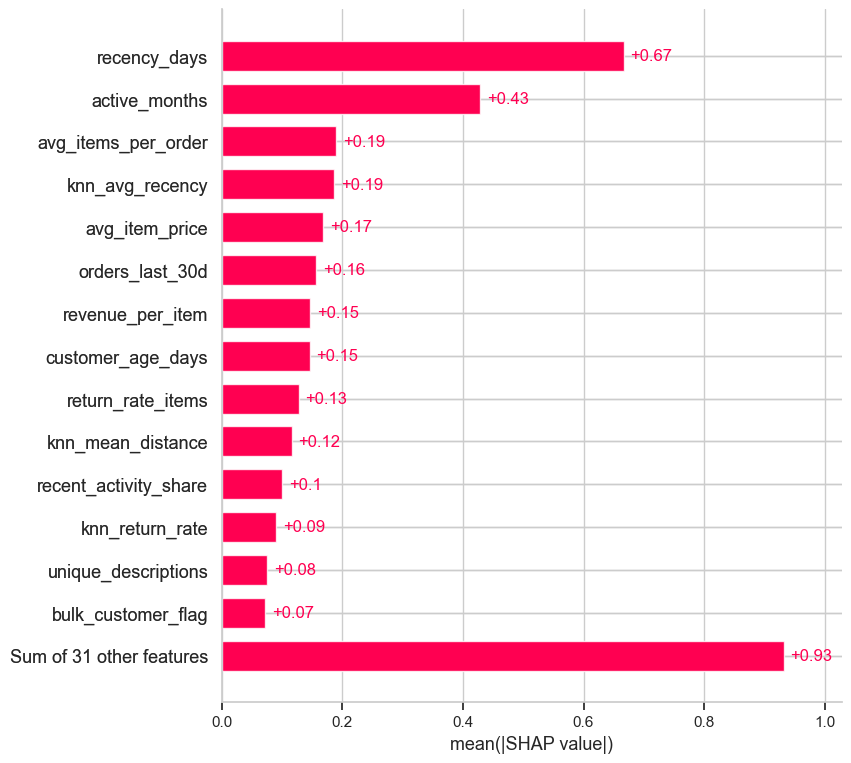

In [ ]:
# SHAP для Logistic Regression
# SHAP считаем на масштабированных признаках, потому что Logistic Regression обучалась внутри Pipeline со StandardScaler
X_train_log_scaled = logreg_int.named_steps["scaler"].transform(X_train_int)
X_test_log_scaled = logreg_int.named_steps["scaler"].transform(X_test_int)

background_size = min(200, X_train_log_scaled.shape[0])
explain_size = min(500, X_test_log_scaled.shape[0])

rng = np.random.default_rng(42)
background_idx = rng.choice(X_train_log_scaled.shape[0], size=background_size, replace=False)
explain_idx = rng.choice(X_test_log_scaled.shape[0], size=explain_size, replace=False)

log_explainer = shap.LinearExplainer(
    logreg_int.named_steps["model"],
    X_train_log_scaled[background_idx]
)

shap_log = log_explainer(X_test_log_scaled[explain_idx])
shap_log.feature_names = interpretation_features

shap.plots.bar(shap_log, max_display=15)



SHAP-интерпретация показывает, что для выбранного клиента прогноз возврата в следующие 90 дней в основном увеличивают признаки, связанные с давностью последней покупки, длительностью активности, размером заказа и поведением похожих клиентов. Наиболее сильный вклад даёт recency_days, затем active_months. Это согласуется с бизнес-логикой: клиенты с выраженной историей активности и похожестью на возвращающихся клиентов чаще получают высокий прогноз вероятности возврата.

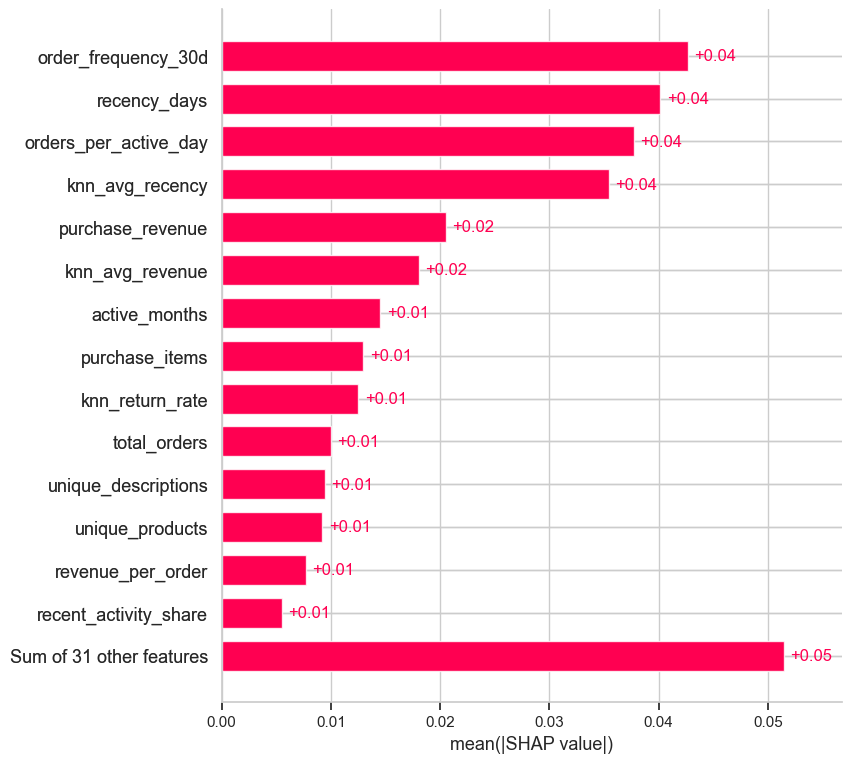

In [ ]:
# SHAP для Random Forest
explain_size = min(500, X_test_int.shape[0])
X_test_rf_sample = X_test_int.sample(explain_size, random_state=42)

rf_explainer = shap.TreeExplainer(rf_int)
shap_rf_raw = rf_explainer.shap_values(X_test_rf_sample)

if isinstance(shap_rf_raw, list):
    shap_rf_values = shap_rf_raw[1]
elif len(np.array(shap_rf_raw).shape) == 3:
    shap_rf_values = np.array(shap_rf_raw)[:, :, 1]
else:
    shap_rf_values = np.array(shap_rf_raw)

rf_base_value = rf_explainer.expected_value[1] if isinstance(rf_explainer.expected_value, (list, np.ndarray)) else rf_explainer.expected_value

shap_rf = shap.Explanation(
    values=shap_rf_values,
    base_values=np.repeat(rf_base_value, shap_rf_values.shape[0]),
    data=X_test_rf_sample.values,
    feature_names=interpretation_features
)

shap.plots.bar(shap_rf, max_display=15)


Локальная интерпретация Random Forest показывает, что для выбранного клиента прогноз возврата повышают признаки частоты и регулярности покупок: order_frequency_30d, orders_per_active_day, recency_days, а также признаки ближайших соседей (knn_avg_recency, knn_return_rate). В отличие от логистической регрессии, вклад признаков распределён более равномерно: модель принимает решение не по одному доминирующему фактору, а по совокупности нескольких поведенческих сигналов.

In [ ]:

# Сравним топ-признаки по среднему абсолютному SHAP для двух моделей
shap_log_importance = pd.DataFrame({
    "feature": interpretation_features,
    "mean_abs_shap_logreg": np.abs(shap_log.values).mean(axis=0)
}).sort_values("mean_abs_shap_logreg", ascending=False)

shap_rf_importance = pd.DataFrame({
    "feature": interpretation_features,
    "mean_abs_shap_rf": np.abs(shap_rf_values).mean(axis=0)
}).sort_values("mean_abs_shap_rf", ascending=False)

shap_compare = (
    shap_log_importance
    .merge(shap_rf_importance, on="feature", how="outer")
    .fillna(0)
)

shap_compare["logreg_rank"] = shap_compare["mean_abs_shap_logreg"].rank(ascending=False)
shap_compare["rf_rank"] = shap_compare["mean_abs_shap_rf"].rank(ascending=False)
shap_compare["rank_diff"] = (shap_compare["logreg_rank"] - shap_compare["rf_rank"]).abs()

display(shap_compare.sort_values("mean_abs_shap_rf", ascending=False).head(20))


,feature,mean_abs_shap_logreg,mean_abs_shap_rf,logreg_rank,rf_rank,rank_diff
24,order_frequency_30d,0.061035,0.042661,16.0,1.0,15.0
31,recency_days,0.667080,0.040144,1.0,2.0,1.0
26,orders_per_active_day,0.061035,0.037710,17.0,3.0,14.0
13,knn_avg_recency,0.187208,0.035420,4.0,4.0,0.0
30,purchase_revenue,0.012183,0.020499,37.0,5.0,32.0
14,knn_avg_revenue,0.037279,0.018039,25.0,6.0,19.0
0,active_months,0.428595,0.014519,2.0,7.0,5.0
29,purchase_items,0.011116,0.012952,38.0,8.0,30.0
16,knn_return_rate,0.090456,0.012523,12.0,9.0,3.0
41,total_orders,0.001932,0.010001,43.0,10.0,33.0


In [ ]:
# LIME: агрегируем локальные объяснения по нескольким объектам, чтобы получить приближённую глобальную важность
def aggregate_lime_importance(model_predict_proba, X_train, X_sample, feature_names, n_instances=50, random_state=42):
  explainer = LimeTabularExplainer(
        training_data=X_train.values,
        feature_names=feature_names,
        class_names=["not_return", "return"],
        mode="classification",
        discretize_continuous=True,
        random_state=random_state
    )

    sample = X_sample.sample(min(n_instances, X_sample.shape[0]), random_state=random_state)
    rows = []

    for _, row in sample.iterrows():
        exp = explainer.explain_instance(
            row.values,
            model_predict_proba,
            num_features=min(10, len(feature_names))
        )
        for rule, weight in exp.as_list(label=1):
            matched_feature = None
            for f in feature_names:
                if f in rule:
                    matched_feature = f
                    break
            rows.append({
                "feature": matched_feature if matched_feature is not None else rule,
                "lime_abs_weight": abs(weight),
                "lime_weight": weight
            })

    return (
        pd.DataFrame(rows)
        .groupby("feature", as_index=False)
        .agg(mean_abs_lime=("lime_abs_weight", "mean"), mean_lime=("lime_weight", "mean"))
        .sort_values("mean_abs_lime", ascending=False)
    )

In [ ]:
lime_logreg_global = aggregate_lime_importance(
        logreg_int.predict_proba,
        X_train_int,
        X_test_int,
        interpretation_features,
        n_instances=50
    )

    lime_rf_global = aggregate_lime_importance(
        rf_int.predict_proba,
        X_train_int,
        X_test_int,
        interpretation_features,
        n_instances=50
    )

    print("LIME Logistic Regression")
    display(lime_logreg_global.head(15))

    print("LIME Random Forest")
    display(lime_rf_global.head(15))

LIME Logistic Regression


,feature,mean_abs_lime,mean_lime
0,active_months,0.201836,-0.028531
16,recency_days,0.179983,-0.016837
5,country_ohe_Spain,0.140868,-0.135524
14,orders_last_30d,0.129739,-0.098338
12,lof_anomaly,0.101915,0.092099
9,knn_mean_distance,0.100962,-0.100962
2,avg_items_per_order,0.088726,0.046479
18,return_items,0.085151,-0.051392
1,avg_item_price,0.075427,0.024052
19,return_rate_items,0.074852,-0.006256


LIME Random Forest


,feature,mean_abs_lime,mean_lime
11,order_frequency_30d,0.050405,0.003064
17,recency_days,0.047412,-0.005050
13,orders_per_active_day,0.043385,0.001647
6,knn_avg_recency,0.041755,-0.004640
16,purchase_revenue,0.032480,-0.000993
7,knn_avg_revenue,0.026068,-0.003728
15,purchase_items,0.020041,-0.003426
0,active_months,0.019435,-0.002449
21,revenue_per_order,0.017793,-0.014756
25,unique_products,0.017769,0.007753


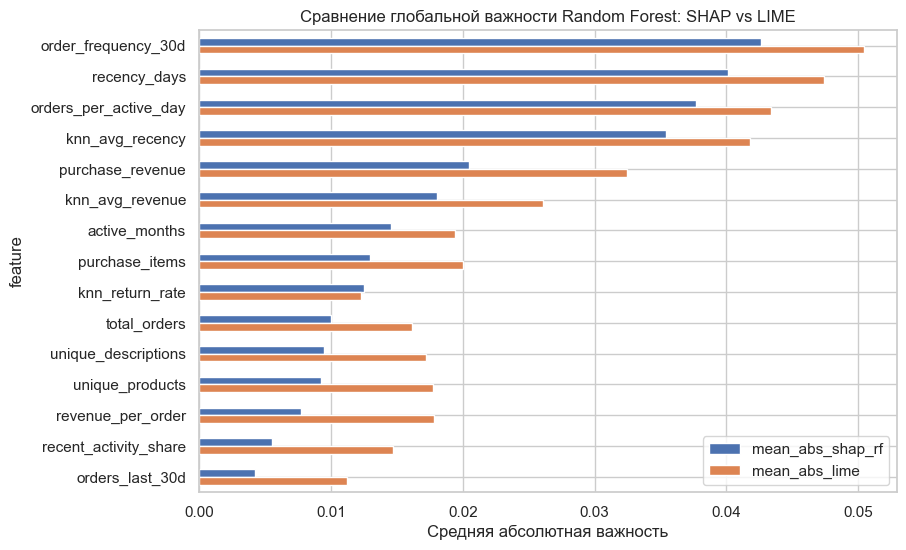

,feature,mean_abs_shap_rf,mean_abs_lime,mean_lime
0,order_frequency_30d,0.042661,0.050405,0.003064
1,recency_days,0.040144,0.047412,-0.005050
2,orders_per_active_day,0.037710,0.043385,0.001647
3,knn_avg_recency,0.035420,0.041755,-0.004640
4,purchase_revenue,0.020499,0.032480,-0.000993
5,knn_avg_revenue,0.018039,0.026068,-0.003728
6,active_months,0.014519,0.019435,-0.002449
7,purchase_items,0.012952,0.020041,-0.003426
8,knn_return_rate,0.012523,0.012277,-0.002553
9,total_orders,0.010001,0.016138,0.006228


In [ ]:
# Визуализация сравнения SHAP и LIME для Random Forest
compare_lime_shap_rf = (
    shap_rf_importance
    .merge(lime_rf_global, on="feature", how="inner")
    .sort_values("mean_abs_shap_rf", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
compare_lime_shap_rf.set_index("feature")[["mean_abs_shap_rf", "mean_abs_lime"]].plot(kind="barh", ax=ax)
plt.title("Сравнение глобальной важности Random Forest: SHAP vs LIME")
plt.xlabel("Средняя абсолютная важность")
plt.gca().invert_yaxis()
plt.show()

display(compare_lime_shap_rf)


## Локальная интерпретация одного клиента

Теперь выберем одного клиента из test и посмотрим, почему модели дали именно такой прогноз. Берём объект с высокой вероятностью возврата по Random Forest — его удобно интерпретировать, потому что модель уверенно считает клиента склонным вернуться.


In [ ]:

# Выбираем объект для локальной интерпретации
local_pos = int(np.argmax(y_proba_rf_int))
local_customer_id = test_fe.iloc[local_pos]["Customer ID"] if "Customer ID" in test_fe.columns else local_pos

print("Позиция объекта в test:", local_pos)
print("Customer ID:", local_customer_id)
print("Фактический target:", y_test_int.iloc[local_pos])
print("Прогноз Logistic Regression:", y_proba_logreg_int[local_pos])
print("Прогноз Random Forest:", y_proba_rf_int[local_pos])

X_local = X_test_int.iloc[[local_pos]]
X_local


Позиция объекта в test: 57
Customer ID: 14735
Фактический target: 1
Прогноз Logistic Regression: 0.9645450148733191
Прогноз Random Forest: 0.9830145356821339


,active_months,avg_item_price,avg_items_per_order,avg_quantity,bulk_customer_flag,country_mode_te,country_ohe_Germany,country_ohe_Spain,country_ohe_United_Kingdom,customer_age_days,...,return_rate_items,return_rate_orders,return_revenue,revenue_per_item,revenue_per_order,strong_anomaly,total_orders,unique_descriptions,unique_products,weekend_share
57,12,3.717774,70.803922,11.387622,0,0.434544,0,0,1,645,...,0.031838,0.294118,-330.45,2.690844,190.575098,0,50,178,168,0.162866


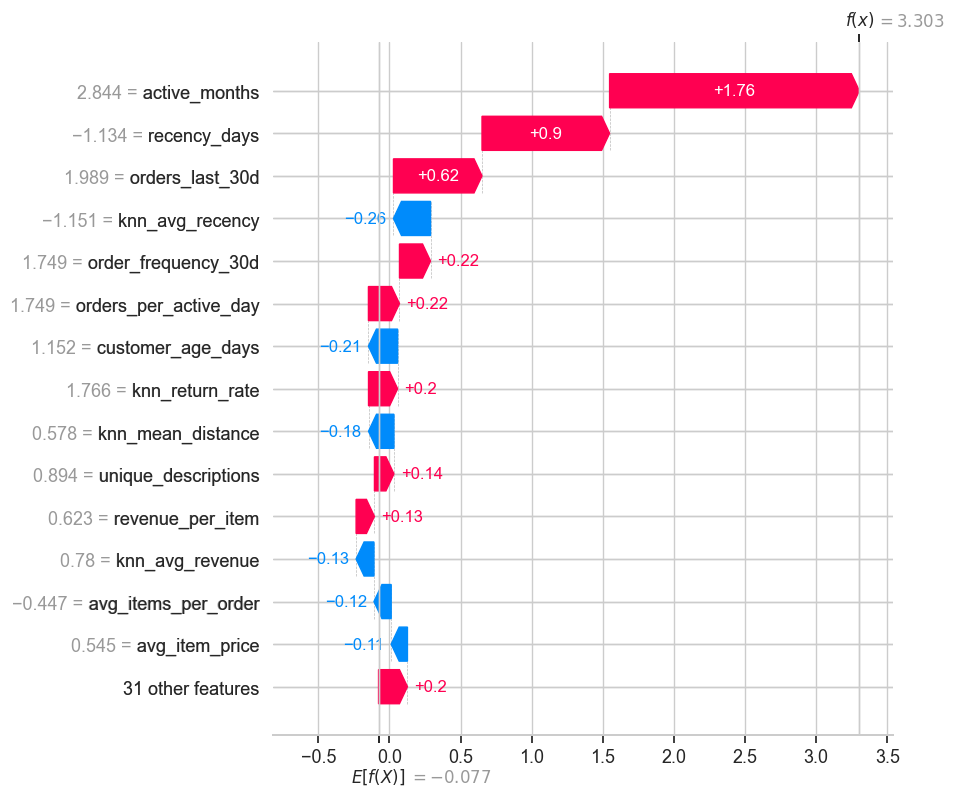

In [ ]:
# Локальный SHAP для Logistic Regression
X_local_scaled = logreg_int.named_steps["scaler"].transform(X_local)
shap_log_local = log_explainer(X_local_scaled)
shap_log_local.feature_names = interpretation_features
shap.plots.waterfall(shap_log_local[0], max_display=15)

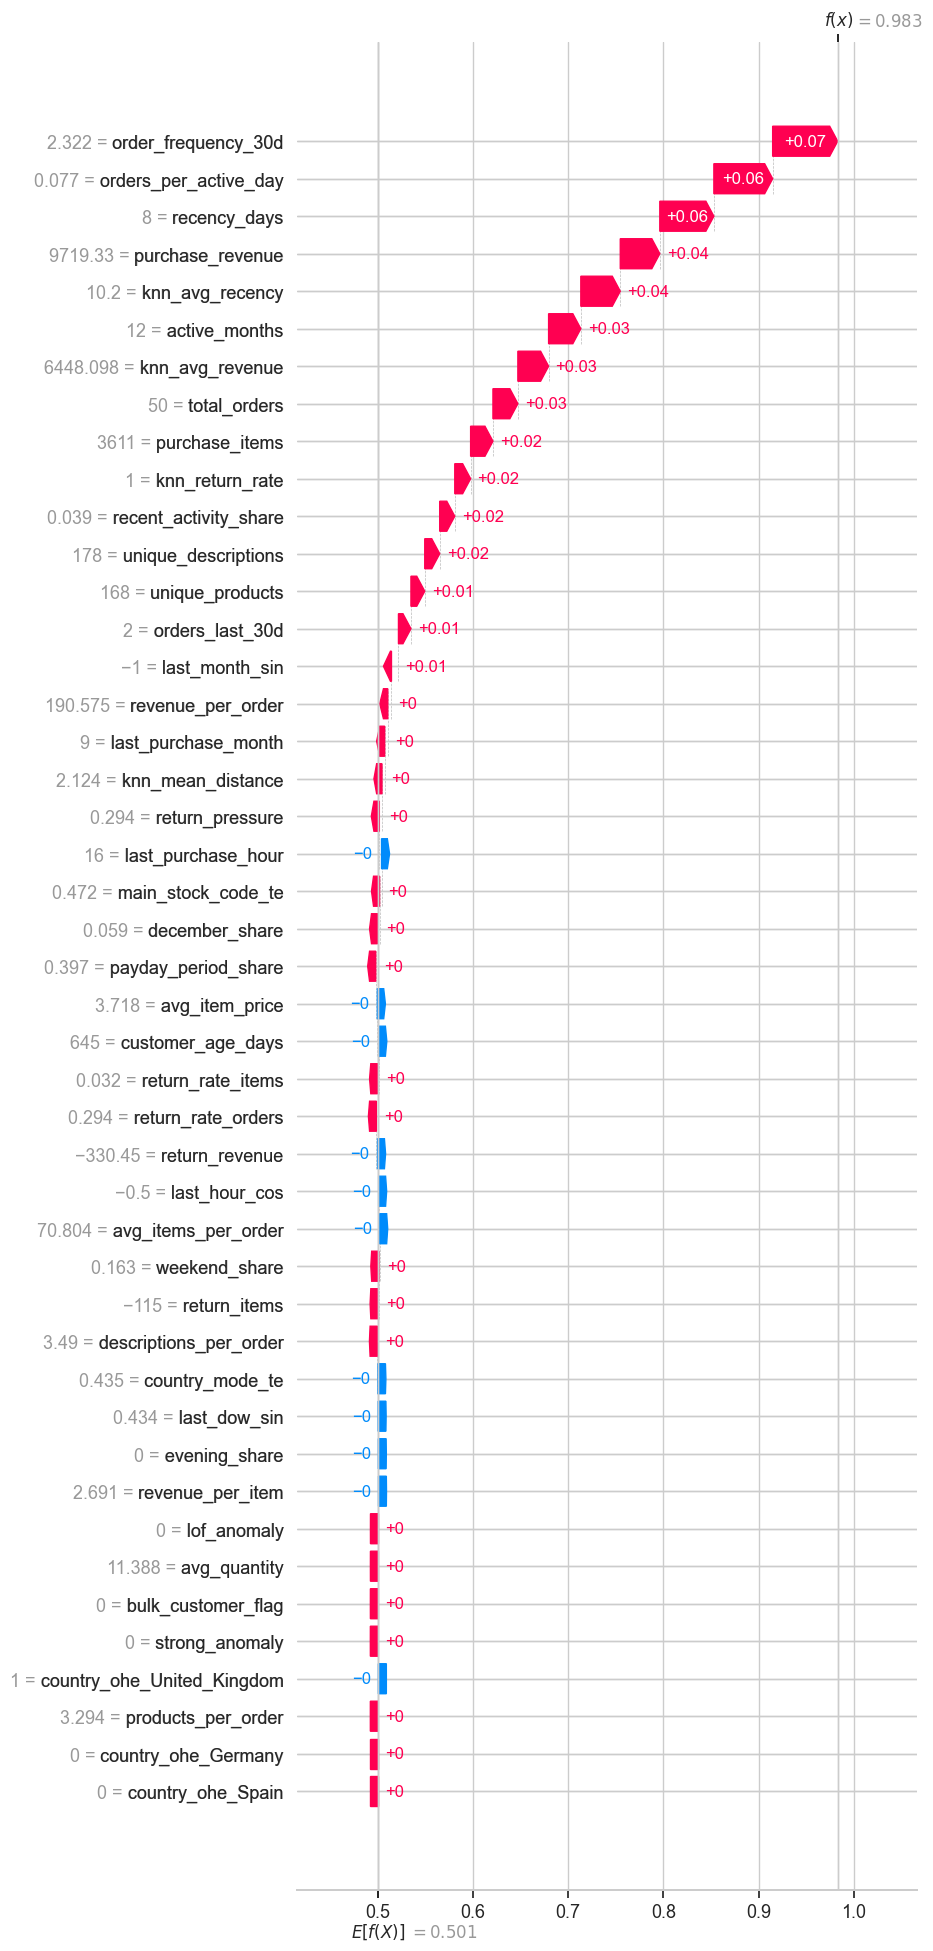

In [ ]:
# Локальный SHAP для Random Forest
shap_rf_local_raw = rf_explainer.shap_values(X_local)
if isinstance(shap_rf_local_raw, list):
    shap_rf_local_values = shap_rf_local_raw[1]
elif len(np.array(shap_rf_local_raw).shape) == 3:
    shap_rf_local_values = np.array(shap_rf_local_raw)[:, :, 1]
else:
    shap_rf_local_values = np.array(shap_rf_local_raw)

rf_base_value = rf_explainer.expected_value[1] if isinstance(rf_explainer.expected_value, (list, np.ndarray)) else rf_explainer.expected_value

shap_rf_local = shap.Explanation(
    values=shap_rf_local_values[0],
    base_values=rf_base_value,
    data=X_local.values[0],
    feature_names=interpretation_features
)

shap.plots.waterfall(shap_rf_local, max_display=45)

Для выбранного клиента обе модели дают высокий прогноз возврата. Logistic Regression сильнее всего повышает прогноз за счёт active_months, recency_days и orders_last_30d, то есть признаков длительности и недавней активности клиента. Random Forest также повышает прогноз из-за частоты заказов, недавней покупки, высокой выручки и поведения похожих клиентов.

In [ ]:

# Локальный LIME для того же объекта.
lime_explainer = LimeTabularExplainer(
    training_data=X_train_int.values,
    feature_names=interpretation_features,
    class_names=["not_return", "return"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

lime_log_local = lime_explainer.explain_instance(
    X_local.values[0],
    logreg_int.predict_proba,
    num_features=min(12, len(interpretation_features))
)

lime_rf_local = lime_explainer.explain_instance(
    X_local.values[0],
    rf_int.predict_proba,
    num_features=min(12, len(interpretation_features))
)

print("LIME Logistic Regression")
display(pd.DataFrame(lime_log_local.as_list(label=1), columns=["rule", "weight"]))

print("LIME Random Forest")
display(pd.DataFrame(lime_rf_local.as_list(label=1), columns=["rule", "weight"]))


LIME Logistic Regression


,rule,weight
0,active_months > 5.00,0.235850
1,recency_days <= 47.75,0.210748
2,country_ohe_Spain <= 0.00,-0.113357
3,orders_last_30d > 0.00,0.111593
4,lof_anomaly <= 0.00,0.104875
5,return_rate_items > 0.01,-0.094777
6,knn_mean_distance > 0.84,-0.092858
7,avg_item_price > 3.57,-0.092644
8,revenue_per_item > 2.34,0.082634
9,bulk_customer_flag <= 0.00,0.077792


LIME Random Forest


,rule,weight
0,order_frequency_30d > 0.57,0.075116
1,orders_per_active_day > 0.02,0.062161
2,recency_days <= 47.75,0.061202
3,knn_avg_recency <= 54.35,0.052990
4,purchase_revenue > 1961.27,0.047124
5,purchase_items > 1121.00,0.026298
6,knn_avg_revenue > 1843.45,0.026181
7,active_months > 5.00,0.022839
8,unique_products > 91.00,0.018642
9,unique_descriptions > 93.00,0.018056


Для выбранного клиента LIME и SHAP дают согласованные локальные интерпретации. В обеих моделях прогноз возврата повышают признаки недавней и регулярной активности: recency_days, active_months, orders_last_30d, order_frequency_30d, orders_per_active_day. Для Random Forest оба метода также выделяют признаки похожих клиентов (knn_avg_recency, knn_return_rate, knn_avg_revenue) и денежные признаки (purchase_revenue, total_orders). Это подтверждает устойчивость интерпретации: клиент получает высокий прогноз не из-за одного случайного признака, а из-за совокупности логичных поведенческих сигналов. При этом SHAP показывает численный вклад признаков в итоговый прогноз, а LIME объясняет решение через локальные правила с порогами.


## SHAP-эмбеддинги, сдвиги и кластеры

SHAP-эмбеддинг — это не исходные признаки клиента, а вектор вкладов признаков в прогноз модели.  
Если два клиента похожи в SHAP-пространстве, значит модель объясняет их прогноз похожим образом, даже если исходные признаки отличаются.

Дальше используем SHAP-эмбеддинги Random Forest, потому что это более гибкая модель.

In [ ]:
def get_rf_shap_embeddings(model, X, feature_names):
    # Возвращает SHAP-эмбеддинги для положительного класса Random Forest
    explainer = shap.TreeExplainer(model)
    raw = explainer.shap_values(X)

    if isinstance(raw, list):
        values = raw[1]
    elif len(np.array(raw).shape) == 3:
        values = np.array(raw)[:, :, 1]
    else:
        values = np.array(raw)

    return pd.DataFrame(values, columns=feature_names, index=X.index)

shap_train_emb = get_rf_shap_embeddings(rf_int, X_train_int, interpretation_features)
shap_test_emb = get_rf_shap_embeddings(rf_int, X_test_int, interpretation_features)

print("SHAP train embeddings:", shap_train_emb.shape)
print("SHAP test embeddings:", shap_test_emb.shape)
display(shap_train_emb.head())

SHAP train embeddings: (4196, 45)
SHAP test embeddings: (1050, 45)


,active_months,avg_item_price,avg_items_per_order,avg_quantity,bulk_customer_flag,country_mode_te,country_ohe_Germany,country_ohe_Spain,country_ohe_United_Kingdom,customer_age_days,...,return_rate_items,return_rate_orders,return_revenue,revenue_per_item,revenue_per_order,strong_anomaly,total_orders,unique_descriptions,unique_products,weekend_share
0,0.007442,-0.003092,-0.002353,-0.004668,0.000018,0.000557,0.0,0.0,-0.000145,-0.004975,...,-0.011058,-0.007485,-0.008451,0.000338,0.006542,0.000033,0.008508,-0.006534,-0.004582,-0.001106
1,0.033061,-0.002143,0.003084,-0.002804,-0.000089,0.000187,0.0,0.0,-0.000023,-0.002045,...,-0.000875,0.001536,-0.001702,-0.000866,0.003039,-0.001024,0.024562,0.017775,0.013907,0.000135
2,0.029702,0.000975,0.002860,-0.000319,0.000030,0.002427,0.0,0.0,0.000089,-0.001858,...,0.003739,0.001723,-0.000401,0.000202,0.004054,0.000036,0.023585,0.015463,0.013705,0.000466
3,0.026285,-0.001102,0.002351,-0.003211,0.000017,-0.003190,0.0,0.0,-0.000046,-0.002682,...,-0.007169,-0.002269,-0.002792,-0.000632,0.006027,0.000085,0.019813,-0.011438,-0.007542,-0.001360
4,-0.008176,0.010629,0.005234,-0.000631,-0.000216,-0.000022,0.0,0.0,-0.000081,-0.001448,...,-0.000437,-0.004091,-0.005326,0.002199,0.005445,0.000012,-0.002930,0.007455,0.008689,-0.001561


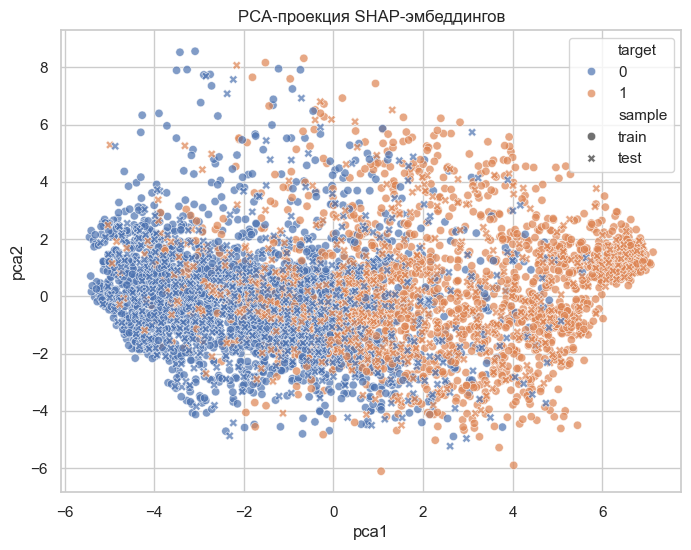

In [ ]:
# PCA-визуализация SHAP-эмбеддингов
shap_scaler = StandardScaler()
shap_train_scaled = shap_scaler.fit_transform(shap_train_emb)
shap_test_scaled = shap_scaler.transform(shap_test_emb)

pca_shap = PCA(n_components=2, random_state=42)
shap_train_pca = pca_shap.fit_transform(shap_train_scaled)
shap_test_pca = pca_shap.transform(shap_test_scaled)

shap_viz_train = pd.DataFrame({
    "pca1": shap_train_pca[:, 0],
    "pca2": shap_train_pca[:, 1],
    "target": y_train_int.values,
    "sample": "train"
})

shap_viz_test = pd.DataFrame({
    "pca1": shap_test_pca[:, 0],
    "pca2": shap_test_pca[:, 1],
    "target": y_test_int.values,
    "sample": "test"
})

shap_viz = pd.concat([shap_viz_train, shap_viz_test], axis=0)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=shap_viz, x="pca1", y="pca2", hue="target", style="sample", alpha=0.7)
plt.title("PCA-проекция SHAP-эмбеддингов")
plt.show()


Доля SHAP-аномалий train: 0.030028598665395614
Доля SHAP-аномалий test: 0.02761904761904762


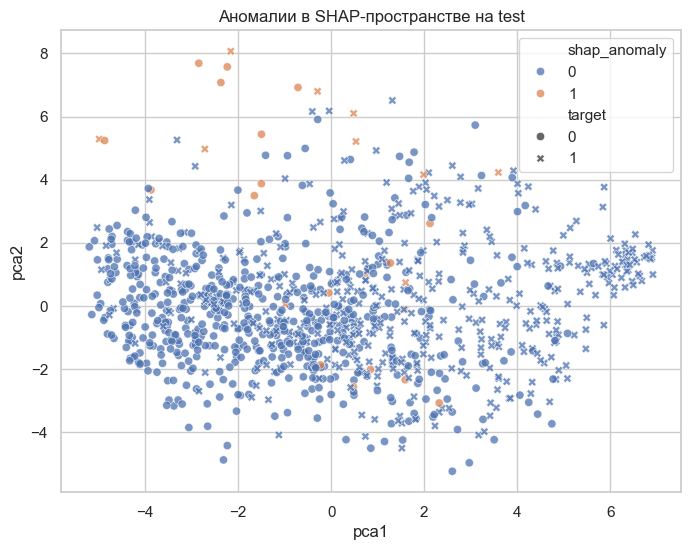

In [ ]:
# Поиск аномалий в SHAP-пространстве (прогноз объясняется нетипичной комбинацией вкладов признаков)
shap_iso = IsolationForest(
    n_estimators=300,
    contamination=0.03,
    random_state=42
)

train_shap_anomaly = (shap_iso.fit_predict(shap_train_scaled) == -1).astype(int)
test_shap_anomaly = (shap_iso.predict(shap_test_scaled) == -1).astype(int)

print("Доля SHAP-аномалий train:", train_shap_anomaly.mean())
print("Доля SHAP-аномалий test:", test_shap_anomaly.mean())

shap_anom_viz = pd.DataFrame({
    "pca1": shap_test_pca[:, 0],
    "pca2": shap_test_pca[:, 1],
    "shap_anomaly": test_shap_anomaly,
    "target": y_test_int.values
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=shap_anom_viz, x="pca1", y="pca2", hue="shap_anomaly", style="target", alpha=0.75)
plt.title("Аномалии в SHAP-пространстве на test")
plt.show()

Мы построили SHAP-эмбеддинги для Random Forest: для каждого клиента были получены вклады признаков в индивидуальный прогноз модели. Затем эмбеддинги были сжаты до двух координат с помощью PCA для визуализации. В этом пространстве были выделены SHAP-аномалии — клиенты, для которых модель формирует прогноз нетипичной комбинацией признаков. Доля таких объектов составила около 3.0% на train и 2.8% на test, то есть сильного сдвига между выборками не наблюдается. На графике аномалии расположены преимущественно на периферии облака точек, что подтверждает их отличие от основной массы клиентов. Такие объекты стоит анализировать отдельно, так как они могут указывать на нестандартные сценарии поведения или потенциальные ошибки модели.

In [ ]:
# Очистка train от SHAP-аномалий
normal_train_mask = train_shap_anomaly == 0

rf_shap_clean = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_shap_clean.fit(X_train_int.loc[normal_train_mask], y_train_int.loc[normal_train_mask])
y_proba_rf_shap_clean = rf_shap_clean.predict_proba(X_test_int)[:, 1]

shap_clean_results = pd.DataFrame({
    "model": ["RF до очистки SHAP-аномалий", "RF после очистки SHAP-аномалий"],
    "roc_auc": [
        roc_auc_score(y_test_int, y_proba_rf_int),
        roc_auc_score(y_test_int, y_proba_rf_shap_clean)
    ],
    "train_size": [
        X_train_int.shape[0],
        normal_train_mask.sum()
    ]
})

display(shap_clean_results)


,model,roc_auc,train_size
0,RF до очистки SHAP-аномалий,0.797565,4196
1,RF после очистки SHAP-аномалий,0.795944,4070


После удаления SHAP-аномалий качество Random Forest немного снизилось: ROC-AUC изменился с 0.7976 до 0.7959. Это говорит о том, что найденные SHAP-аномалии не являются очевидным шумом или ошибками данных. Скорее всего, это реальные клиенты с нетипичным поведением, которые содержат полезную информацию для модели. Поэтому автоматическое удаление таких объектов нецелесообразно.


### Кластеризация SHAP-эмбеддингов

Теперь группируем клиентов не по исходным признакам, а по тому, **какими признаками модель объясняет их прогноз**.

Это помогает найти разные типы клиентов:

- клиенты, для которых важна давность последней покупки;
- клиенты, для которых важна выручка и количество заказов;
- клиенты с нетипичным поведением возвратов;
- клиенты, похожие на оптовых покупателей.

In [ ]:

cluster_scores = []

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(shap_train_scaled)
    sil = silhouette_score(shap_train_scaled, labels)
    cluster_scores.append({"k": k, "silhouette": sil})

cluster_scores = pd.DataFrame(cluster_scores)
display(cluster_scores)

best_k = int(cluster_scores.sort_values("silhouette", ascending=False).iloc[0]["k"])
print("Лучшее k по silhouette:", best_k)

kmeans_shap = KMeans(n_clusters=best_k, random_state=42, n_init=20)
train_cluster_kmeans = kmeans_shap.fit_predict(shap_train_scaled)
test_cluster_kmeans = kmeans_shap.predict(shap_test_scaled)

agg_shap = AgglomerativeClustering(n_clusters=best_k)
train_cluster_agg = agg_shap.fit_predict(shap_train_scaled)

dbscan_shap = DBSCAN(eps=1.5, min_samples=10)
train_cluster_dbscan = dbscan_shap.fit_predict(shap_train_scaled)

print("KMeans clusters:", pd.Series(train_cluster_kmeans).value_counts().sort_index().to_dict())
print("Agglomerative clusters:", pd.Series(train_cluster_agg).value_counts().sort_index().to_dict())
print("DBSCAN clusters:", pd.Series(train_cluster_dbscan).value_counts().sort_index().to_dict())


,k,silhouette
0,2,0.176046
1,3,0.108906
2,4,0.115968
3,5,0.113678
4,6,0.101887


Лучшее k по silhouette: 2
KMeans clusters: {0: 1551, 1: 2645}
Agglomerative clusters: {0: 3351, 1: 845}
DBSCAN clusters: {-1: 4196}


Кластеризация SHAP-эмбеддингов показала, что в объяснениях модели нет жёстко отделённых групп клиентов. Лучшее значение silhouette достигается при k=2, однако само значение невысокое (0.176), поэтому разделение можно считать слабым. KMeans выделяет две достаточно крупные группы клиентов, а иерархическая кластеризация — один основной кластер и один меньший специфичный сегмент. DBSCAN при выбранных параметрах не обнаружил плотных кластеров и отнёс все объекты к шуму. Это говорит о том, что поведение клиентов в SHAP-пространстве скорее непрерывное, без явно изолированных сегментов.

In [ ]:
# Интерпретация кластеров
train_cluster_profile = X_train_int.copy()
train_cluster_profile["target_return_90d"] = y_train_int.values
train_cluster_profile["shap_cluster"] = train_cluster_kmeans

cluster_summary = train_cluster_profile.groupby("shap_cluster").agg(
    clients=("target_return_90d", "size"),
    target_rate=("target_return_90d", "mean"),
    avg_purchase_revenue=("purchase_revenue", "mean") if "purchase_revenue" in X_train_int.columns else (interpretation_features[0], "mean"),
    avg_recency_days=("recency_days", "mean") if "recency_days" in X_train_int.columns else (interpretation_features[0], "mean")
)

display(cluster_summary)

shap_cluster_profile = shap_train_emb.copy()
shap_cluster_profile["shap_cluster"] = train_cluster_kmeans

# Для каждого кластера покажем признаки с наибольшим средним абсолютным SHAP.
cluster_top_features = []
for cl in sorted(shap_cluster_profile["shap_cluster"].unique()):
    part = shap_cluster_profile[shap_cluster_profile["shap_cluster"] == cl].drop(columns="shap_cluster")
    top = part.abs().mean().sort_values(ascending=False).head(5)
    for feature, value in top.items():
        cluster_top_features.append({
            "cluster": cl,
            "feature": feature,
            "mean_abs_shap": value
        })

cluster_top_features = pd.DataFrame(cluster_top_features)
display(cluster_top_features)

,clients,target_rate,avg_purchase_revenue,avg_recency_days
shap_cluster,,,,
0,1551,0.836879,4852.136664,77.212766
1,2645,0.205293,663.102251,283.491871


,cluster,feature,mean_abs_shap
0,0,order_frequency_30d,0.049237
1,0,orders_per_active_day,0.043779
2,0,recency_days,0.041804
3,0,knn_avg_recency,0.034529
4,0,purchase_revenue,0.026268
5,1,recency_days,0.039007
6,1,order_frequency_30d,0.038146
7,1,knn_avg_recency,0.034666
8,1,orders_per_active_day,0.033675
9,1,purchase_revenue,0.018933


На этапе кластеризации SHAP-эмбеддингов мы сгруппировали клиентов по тому, как Random Forest объясняет их прогнозы. Получилось два основных сегмента. Кластер 0 содержит более активных и ценных клиентов: у них высокая доля возврата, высокая средняя выручка и меньшая давность последней покупки. Кластер 1 содержит менее активных клиентов: у них ниже доля возврата, ниже выручка и выше recency. Таким образом, SHAP-кластеры хорошо интерпретируются с бизнес-точки зрения и отражают разные сценарии поведения клиентов.

In [ ]:
# Добавим номер SHAP-кластера как новый признак и проверим, даёт ли это прирост качества
X_train_clustered = X_train_int.copy()
X_test_clustered = X_test_int.copy()

X_train_clustered["shap_cluster"] = train_cluster_kmeans
X_test_clustered["shap_cluster"] = test_cluster_kmeans

# One-Hot для кластера
X_train_clustered = pd.get_dummies(X_train_clustered, columns=["shap_cluster"], prefix="shap_cluster")
X_test_clustered = pd.get_dummies(X_test_clustered, columns=["shap_cluster"], prefix="shap_cluster")
X_test_clustered = X_test_clustered.reindex(columns=X_train_clustered.columns, fill_value=0)

rf_with_cluster = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_with_cluster.fit(X_train_clustered, y_train_int)
y_proba_rf_with_cluster = rf_with_cluster.predict_proba(X_test_clustered)[:, 1]

cluster_feature_results = pd.DataFrame({
    "model": ["RF без SHAP-кластера", "RF + SHAP-кластер"],
    "roc_auc": [
        roc_auc_score(y_test_int, y_proba_rf_int),
        roc_auc_score(y_test_int, y_proba_rf_with_cluster)
    ]
})

display(cluster_feature_results)

,model,roc_auc
0,RF без SHAP-кластера,0.797565
1,RF + SHAP-кластер,0.780767


После добавления SHAP-кластера как дополнительного признака качество Random Forest снизилось с 0.7976 до 0.7808 ROC-AUC. Вероятно, кластер слишком грубо обобщает уже имеющуюся информацию из исходных признаков и приводит к потере части полезных различий между клиентами. Поэтому в финальной модели мы не используем SHAP-кластер как признак, но используем его для интерпретации поведения модели.

## Валидация с SHAP-эмбеддингами и граф влияний в стиле Shapley Flow

Сначала сравним два варианта:

1. модель обучается **только на SHAP-эмбеддингах**;
2. модель обучается на **исходных признаках + SHAP-эмбеддингах**

Внутри кросс-валидации SHAP-эмбеддинги считаются отдельно на каждом фолде. Это нужно, чтобы не было утечки: валидационный фолд не должен участвовать в обучении модели, которая создаёт SHAP-вклады.


In [ ]:

def cv_with_shap_embeddings(X, y, features, n_splits=5, random_state=42):
    # Кросс-валидация: сравниваем модель только на SHAP и модель на X + SHAP
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr = X.iloc[tr_idx].copy()
        X_val = X.iloc[val_idx].copy()
        y_tr = y.iloc[tr_idx].copy()
        y_val = y.iloc[val_idx].copy()

        base_rf = RandomForestClassifier(
            n_estimators=200,
            max_depth=7,
            min_samples_leaf=10,
            random_state=random_state + fold,
            class_weight="balanced",
            n_jobs=-1
        )
        base_rf.fit(X_tr, y_tr)

        tr_shap = get_rf_shap_embeddings(base_rf, X_tr, features)
        val_shap = get_rf_shap_embeddings(base_rf, X_val, features)

        # Только SHAP-эмбеддинги
        meta_shap = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=random_state)
        pipe_shap = Pipeline([
            ("scaler", StandardScaler()),
            ("model", meta_shap)
        ])
        pipe_shap.fit(tr_shap, y_tr)
        pred_shap = pipe_shap.predict_proba(val_shap)[:, 1]

        # Исходные признаки + SHAP-эмбеддинги
        X_tr_concat = pd.concat([
            X_tr.reset_index(drop=True),
            tr_shap.reset_index(drop=True).add_prefix("shap__")
        ], axis=1)
        X_val_concat = pd.concat([
            X_val.reset_index(drop=True),
            val_shap.reset_index(drop=True).add_prefix("shap__")
        ], axis=1)

        meta_concat = LogisticRegression(max_iter=3000, class_weight="balanced", random_state=random_state)
        pipe_concat = Pipeline([
            ("scaler", StandardScaler()),
            ("model", meta_concat)
        ])
        pipe_concat.fit(X_tr_concat, y_tr)
        pred_concat = pipe_concat.predict_proba(X_val_concat)[:, 1]

        rows.append({
            "fold": fold,
            "roc_auc_shap_only": roc_auc_score(y_val, pred_shap),
            "roc_auc_features_plus_shap": roc_auc_score(y_val, pred_concat)
        })

    return pd.DataFrame(rows)

shap_cv_results = cv_with_shap_embeddings(
    X_train_int.reset_index(drop=True),
    y_train_int.reset_index(drop=True),
    interpretation_features,
    n_splits=5,
    random_state=42
)

display(shap_cv_results)
display(shap_cv_results.mean(numeric_only=True).to_frame("mean_score"))


,fold,roc_auc_shap_only,roc_auc_features_plus_shap
0,1,0.756080,0.743209
1,2,0.741109,0.741634
2,3,0.745298,0.736096
3,4,0.782903,0.779568
4,5,0.771906,0.759808


,mean_score
fold,3.000000
roc_auc_shap_only,0.759459
roc_auc_features_plus_shap,0.752063


Кросс-валидация показала, что SHAP-эмбеддинги могут использоваться как отдельное представление данных, но уступают исходным признакам по качеству. Конкатенация исходных признаков и SHAP-эмбеддингов не дала прироста ROC-AUC, вероятно, из-за дублирования информации и добавления шума.


#### Граф взаимосвязей признаков и приближение Shapley Flow

Полный Shapley Flow строит причинно-направленный граф и распределяет вклад признаков по путям графа. Мы воспроизводим приближённый вариант:

1. строим граф связей между признаками по сильным корреляциям;
2. берём средний абсолютный SHAP как силу влияния признака на прогноз;
3. смотрим, через какие группы связанных признаков проходит основной вклад модели.

Это не заменяет строгую causal-интерпретацию, но помогает понять, какие признаки образуют связанные блоки: например, блок активности клиента, блок давности покупки, блок выручки, блок возвратов.

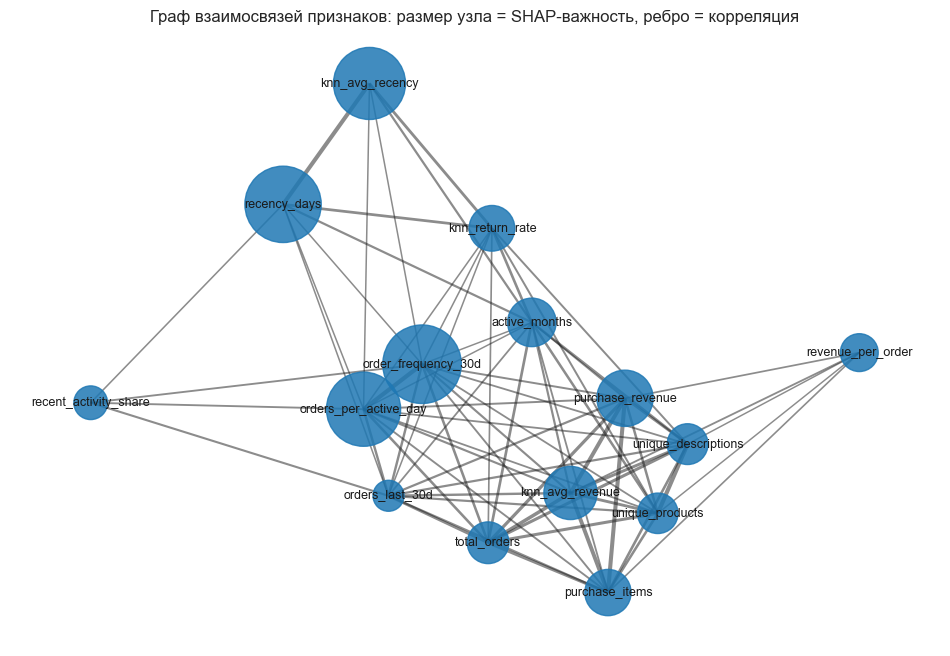

,component,features,component_shap_strength,n_features
0,1,"[active_months, unique_products, unique_descri...",0.280607,15


In [ ]:

# Граф признаков по корреляциям + SHAP-важности
# Берём топ признаков по SHAP, чтобы граф был читаемым
top_graph_features = shap_rf_importance.head(15)["feature"].tolist()

corr = X_train_int[top_graph_features].corr().abs().fillna(0)
shap_strength = shap_rf_importance.set_index("feature")["mean_abs_shap_rf"].to_dict()

G = nx.Graph()

for f in top_graph_features:
    G.add_node(f, shap_strength=shap_strength.get(f, 0))

corr_threshold = 0.35
for i, f1 in enumerate(top_graph_features):
    for f2 in top_graph_features[i+1:]:
        if corr.loc[f1, f2] >= corr_threshold:
            G.add_edge(f1, f2, weight=corr.loc[f1, f2])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42, k=0.7)
node_sizes = [3000 * (G.nodes[n]["shap_strength"] / max(shap_strength.values())) + 200 for n in G.nodes]
edge_widths = [3 * G[u][v]["weight"] for u, v in G.edges]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, alpha=0.85)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=9)
plt.title("Граф взаимосвязей признаков: размер узла = SHAP-важность, ребро = корреляция")
plt.axis("off")
plt.show()

graph_components = []
for component_id, component in enumerate(nx.connected_components(G), start=1):
    component = list(component)
    graph_components.append({
        "component": component_id,
        "features": component,
        "component_shap_strength": sum(shap_strength.get(f, 0) for f in component),
        "n_features": len(component)
    })

graph_components = pd.DataFrame(graph_components).sort_values("component_shap_strength", ascending=False)
display(graph_components)


In [ ]:

# Используем компоненты графа как групповые признаки и проверяем качество.
# Для каждой компоненты считаем сумму SHAP-вкладов признаков внутри этой компоненты.
def build_flow_component_features(shap_emb, graph_components):
    result = pd.DataFrame(index=shap_emb.index)
    for _, row in graph_components.iterrows():
        cols = [c for c in row["features"] if c in shap_emb.columns]
        if len(cols) > 0:
            result[f"flow_component_{int(row['component'])}"] = shap_emb[cols].sum(axis=1)
    return result

train_flow_features = build_flow_component_features(shap_train_emb, graph_components)
test_flow_features = build_flow_component_features(shap_test_emb, graph_components)

flow_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=42))
])

flow_model.fit(train_flow_features, y_train_int)
y_proba_flow = flow_model.predict_proba(test_flow_features)[:, 1]

X_train_flow_concat = pd.concat([
    X_train_int.reset_index(drop=True),
    train_flow_features.reset_index(drop=True)
], axis=1)
X_test_flow_concat = pd.concat([
    X_test_int.reset_index(drop=True),
    test_flow_features.reset_index(drop=True)
], axis=1)

rf_flow_concat = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    min_samples_leaf=10,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)
rf_flow_concat.fit(X_train_flow_concat, y_train_int)
y_proba_rf_flow_concat = rf_flow_concat.predict_proba(X_test_flow_concat)[:, 1]

flow_results = pd.DataFrame({
    "model": [
        "RF исходные признаки",
        "LogReg только flow-компоненты",
        "RF исходные признаки + flow-компоненты"
    ],
    "roc_auc": [
        roc_auc_score(y_test_int, y_proba_rf_int),
        roc_auc_score(y_test_int, y_proba_flow),
        roc_auc_score(y_test_int, y_proba_rf_flow_concat)
    ]
})

display(flow_results)


,model,roc_auc
0,RF исходные признаки,0.797565
1,LogReg только flow-компоненты,0.796699
2,RF исходные признаки + flow-компоненты,0.796390


Для сравнения SHAP и flow-подхода мы использовали исходную неочищенную выборку. По SHAP-аномалиям доля нестандартных объектов была близкой на train и test: около 3.0% на train и 2.8% на test. Это говорит о том, что сильного сдвига между выборками по характеру объяснений модели не наблюдается. Аномалии в основном расположены на периферии SHAP-пространства, то есть это клиенты, для которых модель принимает решение нетипичным образом, но они не выглядят как массовый сдвиг тестовой выборки.

Структура кластеров также не изменилась радикально. В SHAP-пространстве KMeans выделил два основных сегмента: активных клиентов с высокой долей возврата и высокой выручкой, а также менее активных клиентов с низкой долей возврата и большей давностью последней покупки. При переходе к flow-подходу признаки объединились в одну крупную связанную компоненту, включающую активность клиента, частоту заказов, recency, выручку и KNN-признаки. Это показывает, что модель опирается не на разрозненные признаки, а на единый связанный блок клиентской активности.

Улучшить качество модели за счёт этих диагностических признаков не удалось. Удаление SHAP-аномалий немного снизило ROC-AUC с 0.7976 до 0.7959. Добавление SHAP-кластера также ухудшило качество до 0.7808. Обучение только на SHAP-эмбеддингах дало средний ROC-AUC около 0.759, что ниже основной модели. Flow-компоненты оказались наиболее удачным сжатым представлением: Logistic Regression только на flow-компонентах дала ROC-AUC 0.7967, почти как Random Forest на исходных признаках 0.7976. Однако добавление flow-компонент к исходным признакам не улучшило результат.